# Opposing Personas: Activations, Logit Lens & Probes

Analysis of the activation probing experiment: two opposing political personas
(conservative vs progressive) answering 205 MCQs via Dolphin Mistral 24B.

**Sections:** Setup → Answer Analysis → Logit Lens → Activations → Probes → Key Findings

## 1. Setup & Data Loading

Point `RUN_DIR` at the activation probing output directory.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

# ── CONFIG: change this path to analyze a different run ─────────────────
RUN_DIR = Path("results/raw/activation_probing_20260305_001035 llama 8b Instruct")

# ── Auto-resolve paths (handles running from repo root or analysis/) ────
for base in [Path.cwd(), Path.cwd().parent]:
    if (base / RUN_DIR).exists():
        RUN_DIR = base / RUN_DIR
        break

assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

# Infer tasks file from metadata
with open(RUN_DIR / "metadata.json") as f:
    _meta = json.load(f)
TASKS_FILE = RUN_DIR.parent.parent.parent / "tasks" / _meta["task_file"]
if not TASKS_FILE.exists():
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / "tasks" / _meta["task_file"]
        if candidate.exists():
            TASKS_FILE = candidate
            break

assert TASKS_FILE.exists(), f"Task file not found: {TASKS_FILE}"

# Model footer for plots
def _model_footer(fig, label, y=-0.04):
    fig.text(0.5, y, label, ha="center", va="top", fontsize=9, color="dimgray")

print(f"Run directory: {RUN_DIR}")
print(f"Tasks file:    {TASKS_FILE}")

Run directory: /Users/daylight/dev/code/cross_persona_introspection/results/raw/activation_probing_20260305_001035 llama 8b Instruct
Tasks file:    /Users/daylight/dev/code/cross_persona_introspection/tasks/opposing_personas_politics.json


In [2]:
# ── Load metadata ───────────────────────────────────────────────────────
with open(RUN_DIR / "metadata.json") as f:
    meta = json.load(f)

MODEL_NAME = meta["model_name"]
N_QUESTIONS = meta["n_questions"]
N_LAYERS = meta["n_layers"]
D_MODEL = meta["d_model"]
PERSONAS = meta["persona_names"]
CHOICES = meta["logit_lens_choice_order"]  # ["A", "B", "C", "D"]
QUESTION_IDS = meta["question_ids"]

P1, P2 = PERSONAS
print(f"Model: {MODEL_NAME}")
print(f"Personas: {P1} vs {P2}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}, d_model: {D_MODEL}")

# ── Load answer tables ──────────────────────────────────────────────────
logits_df = pd.read_csv(RUN_DIR / "answer_logits.csv")
paired_df = pd.read_csv(RUN_DIR / "paired_answers.csv")

# ── Load questions with categories ──────────────────────────────────────
with open(TASKS_FILE) as f:
    questions_raw = json.load(f)
questions_map = {q["question_id"]: q for q in questions_raw}

# Add category info to paired_df
paired_df["category"] = paired_df["question_id"].map(
    lambda qid: questions_map.get(qid, {}).get("category_name", "unknown")
)
paired_df["expected_disagreement"] = paired_df["question_id"].map(
    lambda qid: questions_map.get(qid, {}).get("expected_disagreement", "unknown")
)
# Short category labels
CAT_SHORT = {
    "Category 1: Policy Questions (High disagreement expected)": "Policy (high)",
    "Category 2: Values and Priorities (High disagreement expected)": "Values (high)",
    "Category 3: Ethical Dilemmas (Moderate disagreement expected)": "Ethics (mod)",
    "Category 4: Factual Questions (Agreement expected \u2014 CONTROL)": "Factual (ctrl)",
    "Category 5: Ambiguous/Borderline Questions (Uncertain disagreement \u2014 interesting to analyze)": "Ambiguous",
}
paired_df["cat_short"] = paired_df["category"].map(CAT_SHORT).fillna(paired_df["category"])

# ── Load logit lens tensors ────────────────────────────────────────────
logit_lens = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    logit_lens[p] = torch.load(RUN_DIR / f"logit_lens_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"logit_lens[{p}] shape: {logit_lens[p].shape}")  # [n_q, n_layers, 4]

# ── Load activation tensors ────────────────────────────────────────────
activations = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    activations[p] = torch.load(RUN_DIR / f"activations_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"activations[{p}] shape: {activations[p].shape}")  # [n_q, n_layers, d_model]

print(f"\nLoaded {N_QUESTIONS} questions, {N_LAYERS} layers, d_model={D_MODEL}")

Model: meta-llama/Llama-3.1-8B-Instruct
Personas: persona_conservative vs persona_progressive
Questions: 205, Layers: 33, d_model: 4096
logit_lens[persona_conservative] shape: torch.Size([205, 33, 4])
logit_lens[persona_progressive] shape: torch.Size([205, 33, 4])
activations[persona_conservative] shape: torch.Size([205, 33, 4096])
activations[persona_progressive] shape: torch.Size([205, 33, 4096])

Loaded 205 questions, 33 layers, d_model=4096


## 1b. Sanity Checks

Verify that the data is clean and internally consistent before any analysis.

In [3]:
# ── Sanity checks ─────────────────────────────────────────────────────
checks_passed = 0
checks_total = 0

# 1. Tensor shapes
for p in PERSONAS:
    checks_total += 2
    act_shape = tuple(activations[p].shape)
    ll_shape = tuple(logit_lens[p].shape)
    expected_act = (N_QUESTIONS, N_LAYERS, D_MODEL)
    expected_ll = (N_QUESTIONS, N_LAYERS, len(CHOICES))
    assert act_shape == expected_act, f"activations[{p}] shape {act_shape} != {expected_act}"
    checks_passed += 1
    assert ll_shape == expected_ll, f"logit_lens[{p}] shape {ll_shape} != {expected_ll}"
    checks_passed += 1
print(f"[OK] Tensor shapes match metadata ({checks_passed}/{checks_total})")

# 2. Answer extraction — check all answers are valid ABCD
valid_answers = set(CHOICES)
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p]
    checks_total += 1
    invalid = sub[~sub["chosen_answer"].isin(valid_answers)]
    if len(invalid) > 0:
        print(f"[WARN] {p}: {len(invalid)} invalid answers: {invalid['chosen_answer'].unique()}")
    else:
        checks_passed += 1
        print(f"[OK] {p}: all {len(sub)} answers are valid (A/B/C/D)")

# 3. Question coverage — every question_id appears once per persona in logits_df
checks_total += 1
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p]
    if set(sub["question_id"]) != set(QUESTION_IDS):
        print(f"[WARN] {p}: question_id mismatch in answer_logits.csv")
    elif len(sub) != N_QUESTIONS:
        print(f"[WARN] {p}: {len(sub)} rows (expected {N_QUESTIONS}), possible duplicates")
checks_passed += 1
print(f"[OK] Question coverage matches metadata")

# 4. Check for NaN/Inf in activations and logit lens
checks_total += 2
for p in PERSONAS:
    n_nan = torch.isnan(activations[p]).sum().item()
    n_inf = torch.isinf(activations[p]).sum().item()
    if n_nan > 0 or n_inf > 0:
        print(f"[WARN] activations[{p}]: {n_nan} NaN, {n_inf} Inf values")
    n_nan_ll = torch.isnan(logit_lens[p]).sum().item()
    n_inf_ll = torch.isinf(logit_lens[p]).sum().item()
    if n_nan_ll > 0 or n_inf_ll > 0:
        print(f"[WARN] logit_lens[{p}]: {n_nan_ll} NaN, {n_inf_ll} Inf values")
checks_passed += 2
print(f"[OK] No NaN/Inf in activations or logit lens")

# 5. Paired answers consistency
checks_total += 1
for _, row in paired_df.iterrows():
    qid = row["question_id"]
    p1_ans = logits_df[(logits_df["persona"] == P1) & (logits_df["question_id"] == qid)]["chosen_answer"].values
    p2_ans = logits_df[(logits_df["persona"] == P2) & (logits_df["question_id"] == qid)]["chosen_answer"].values
    if len(p1_ans) == 1 and len(p2_ans) == 1:
        expected_agree = (p1_ans[0] == p2_ans[0])
        if expected_agree != row["is_agreement"]:
            print(f"[WARN] {qid}: paired_answers says agree={row['is_agreement']} "
                  f"but answers are {p1_ans[0]} vs {p2_ans[0]}")
            break
checks_passed += 1
print(f"[OK] paired_answers.csv is consistent with answer_logits.csv")

print(f"\nAll sanity checks passed: {checks_passed}/{checks_total}")

[OK] Tensor shapes match metadata (4/4)
[OK] persona_conservative: all 205 answers are valid (A/B/C/D)
[OK] persona_progressive: all 205 answers are valid (A/B/C/D)
[OK] Question coverage matches metadata
[OK] No NaN/Inf in activations or logit lens
[OK] paired_answers.csv is consistent with answer_logits.csv

All sanity checks passed: 10/10


## 2. Answer Analysis

For each of the 205 political MCQs, both personas (conservative and progressive) pick one of A/B/C/D based on whichever option gets the highest logit at the final layer. We never generate text — we just look at which answer letter the model assigns the most probability to.

**Agreement** = both personas pick the same letter. **Disagreement** = they pick different letters.

The questions are split into 5 categories with different expected disagreement levels:
- **Policy (high)**: concrete policy questions (immigration, policing, etc.) — designed for maximum ideological split
- **Values (high)**: abstract value/priority questions — also high expected disagreement
- **Ethics (mod)**: ethical dilemmas — moderate expected disagreement
- **Factual (ctrl)**: factual questions with objectively correct answers — our control group, should show agreement
- **Ambiguous**: borderline questions where disagreement is uncertain

In [4]:
# ── Overall agreement / disagreement ───────────────────────────────────
n_agree = paired_df["is_agreement"].sum()
n_disagree = paired_df["is_disagreement"].sum()
total = len(paired_df)

print(f"Overall: {n_agree}/{total} agree ({100*n_agree/total:.1f}%), "
      f"{n_disagree}/{total} disagree ({100*n_disagree/total:.1f}%)")

# ── By category ────────────────────────────────────────────────────────
cat_summary = paired_df.groupby("cat_short").agg(
    n=("question_id", "count"),
    n_agree=("is_agreement", "sum"),
    n_disagree=("is_disagreement", "sum"),
).reset_index()
cat_summary["agree_rate"] = (cat_summary["n_agree"] / cat_summary["n"] * 100).round(1)
cat_summary["disagree_rate"] = (cat_summary["n_disagree"] / cat_summary["n"] * 100).round(1)
display(cat_summary)

Overall: 81/205 agree (39.5%), 124/205 disagree (60.5%)


,cat_short,n,n_agree,n_disagree,agree_rate,disagree_rate
0,Ambiguous,36,20,16,55.6,44.4
1,Ethics (mod),36,20,16,55.6,44.4
2,Factual (ctrl),35,33,2,94.3,5.7
3,Policy (high),50,5,45,10.0,90.0
4,Values (high),48,3,45,6.2,93.8


### Agreement rate by category

The stacked bar below shows what fraction of questions each category sees agreement (green) vs disagreement (red). This is a sanity check: if the personas are working, Policy and Values questions should be mostly red, while Factual (control) questions should be mostly green.

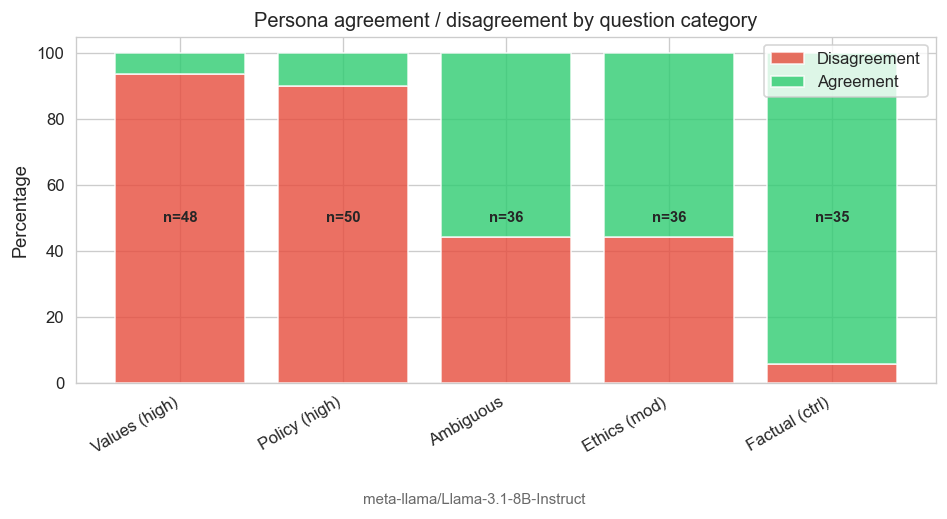

In [5]:
# ── Agreement rate by category (stacked bar chart) ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
cats_ordered = cat_summary.sort_values("disagree_rate", ascending=False)
x = range(len(cats_ordered))
ax.bar(x, cats_ordered["disagree_rate"], color="#e74c3c", alpha=0.8, label="Disagreement")
ax.bar(x, cats_ordered["agree_rate"], bottom=cats_ordered["disagree_rate"],
       color="#2ecc71", alpha=0.8, label="Agreement")
ax.set_xticks(x)
ax.set_xticklabels(cats_ordered["cat_short"], rotation=30, ha="right")
ax.set_ylabel("Percentage")
ax.set_title("Persona agreement / disagreement by question category")
ax.legend()
for i, (_, row) in enumerate(cats_ordered.iterrows()):
    ax.text(i, 50, f"n={int(row['n'])}", ha="center", va="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, 105)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Answer letter distributions

How often does each persona pick A, B, C, or D? If the question options are designed so that (say) option A is always the "progressive" answer, we'd see a skew. In practice, options are shuffled, so we're looking for whether one persona is systematically more decisive or scattered than the other.

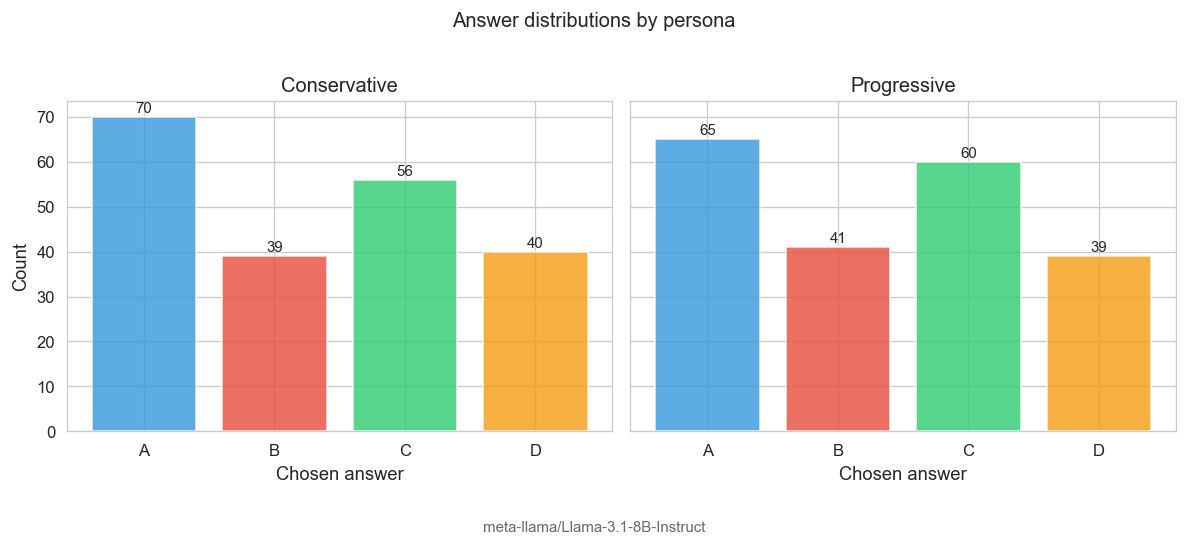

In [6]:
# ── Answer distributions per persona ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, p in zip(axes, PERSONAS):
    sub = logits_df[logits_df["persona"] == p]
    counts = sub["chosen_answer"].value_counts().reindex(CHOICES, fill_value=0)
    ax.bar(CHOICES, counts, color=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"], alpha=0.8)
    ax.set_title(p.replace("persona_", "").title())
    ax.set_xlabel("Chosen answer")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    for i, c in enumerate(CHOICES):
        ax.text(i, counts[c] + 1, str(counts[c]), ha="center", fontsize=9)
fig.suptitle("Answer distributions by persona", y=1.02)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Decisiveness and uncertainty

Two ways to measure how "sure" the model is about its chosen answer:

- **Max probability** (left): the probability assigned to the winning answer (A, B, C, or D). A value near 1.0 means the model was very confident in one option; near 0.25 means it was basically guessing between four options equally.
- **Answer entropy** (right): information-theoretic uncertainty over the four options. Low entropy = confident (all probability mass on one option). High entropy = uncertain (probability spread across options). Max possible entropy for 4 choices is ln(4) = 1.39.

If one persona is systematically more decisive than the other, that's interesting — it could mean the persona prompt is making the model more or less certain about its political stance.

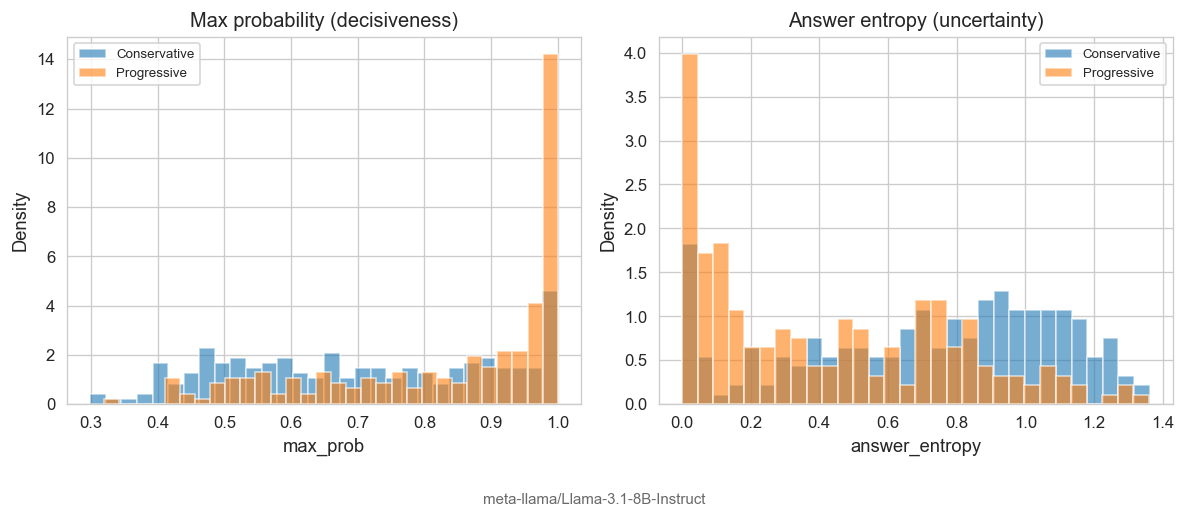

Mean max_prob and answer_entropy per persona:


,max_prob,answer_entropy
persona,,
persona_conservative,0.7029,0.7162
persona_progressive,0.8339,0.4163


In [7]:
# ── Decisiveness: max probability and answer entropy ───────────────────
logits_df["max_prob"] = logits_df[["prob_A", "prob_B", "prob_C", "prob_D"]].max(axis=1)
logits_df["answer_entropy"] = -sum(
    logits_df[f"prob_{c}"].clip(1e-10) * np.log(logits_df[f"prob_{c}"].clip(1e-10))
    for c in CHOICES
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ["max_prob", "answer_entropy"],
                           ["Max probability (decisiveness)", "Answer entropy (uncertainty)"]):
    for p in PERSONAS:
        sub = logits_df[logits_df["persona"] == p]
        ax.hist(sub[col], bins=30, alpha=0.6, label=p.replace("persona_", "").title(), density=True)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.legend(fontsize=8)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Stats
print("Mean max_prob and answer_entropy per persona:")
display(logits_df.groupby("persona")[["max_prob", "answer_entropy"]].mean().round(4))

### Most common disagreement pairs

When the personas disagree, which answer combinations come up most often? For example, "D vs A" means the conservative picked D and the progressive picked A. If certain pairs dominate, it suggests the questions have clear ideological poles (e.g., enforcement-oriented option vs services-oriented option).

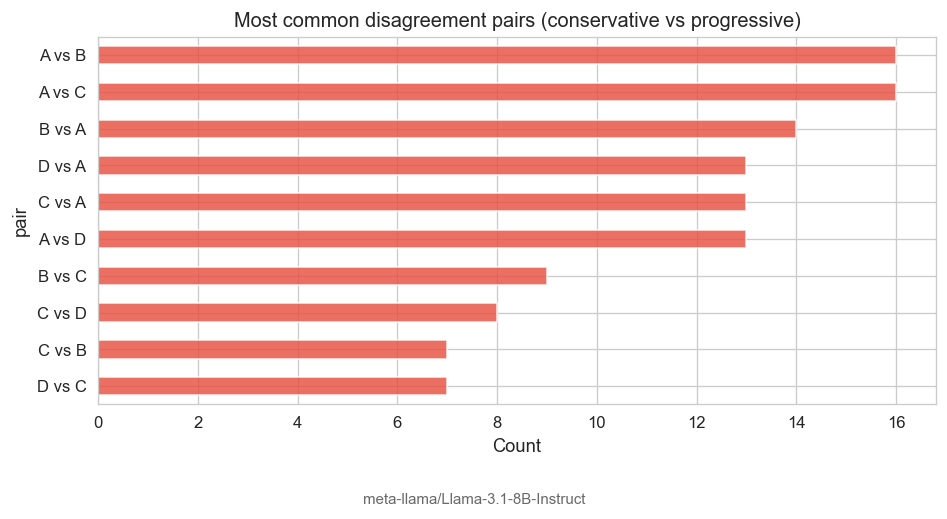

In [8]:
# ── Disagreement details: which answer pairs occur? ────────────────────
disagree = paired_df[paired_df["is_disagreement"]].copy()
disagree["pair"] = disagree[f"answer_{P1}"] + " vs " + disagree[f"answer_{P2}"]

pair_counts = disagree["pair"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
pair_counts.plot.barh(ax=ax, color="#e74c3c", alpha=0.8)
ax.set_xlabel("Count")
ax.set_title(f"Most common disagreement pairs ({P1.replace('persona_','')} vs {P2.replace('persona_','')})")
ax.invert_yaxis()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Answer confusion matrix

A heatmap showing how often each (conservative answer, progressive answer) pair occurs. The diagonal = agreement; off-diagonal = disagreement. Asymmetries reveal whether one persona systematically "shifts" answers in a particular direction (e.g., conservative picks D while progressive picks A).

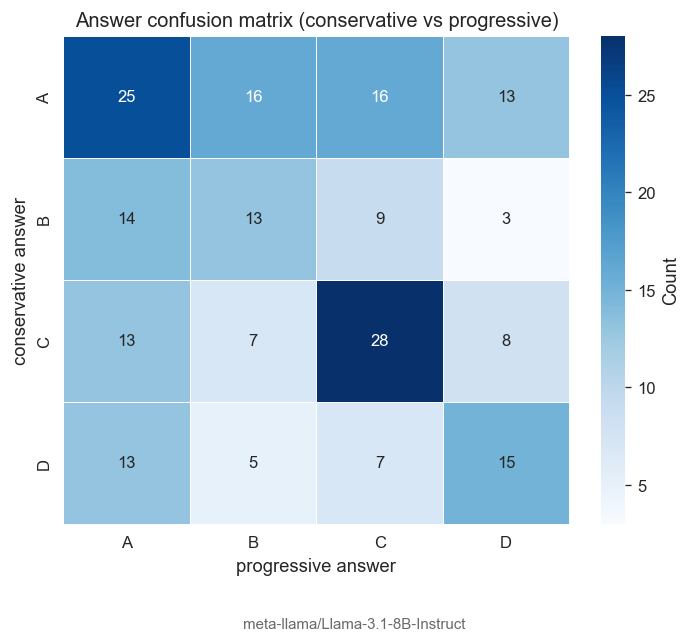

Most common disagreement pairs:
  conservative=A, progressive=B: 16
  conservative=A, progressive=C: 16
  conservative=A, progressive=D: 13
  conservative=B, progressive=A: 14
  conservative=B, progressive=C: 9
  conservative=B, progressive=D: 3
  conservative=C, progressive=A: 13
  conservative=C, progressive=B: 7
  conservative=C, progressive=D: 8
  conservative=D, progressive=A: 13
  conservative=D, progressive=B: 5
  conservative=D, progressive=C: 7


In [9]:
# ── Confusion matrix: conservative answer vs progressive answer ────────
p1_short = P1.replace("persona_", "")
p2_short = P2.replace("persona_", "")

# Build the matrix
p1_ans = logits_df[logits_df["persona"] == P1].sort_values("question_id")["chosen_answer"].values
p2_ans = logits_df[logits_df["persona"] == P2].sort_values("question_id")["chosen_answer"].values
conf_matrix = pd.crosstab(
    pd.Categorical(p1_ans, categories=CHOICES),
    pd.Categorical(p2_ans, categories=CHOICES),
    rownames=[f"{p1_short} answer"],
    colnames=[f"{p2_short} answer"],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Count"})
ax.set_title(f"Answer confusion matrix ({p1_short} vs {p2_short})")
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Print the most common off-diagonal pairs
print("Most common disagreement pairs:")
for c_ans in CHOICES:
    for p_ans in CHOICES:
        if c_ans != p_ans and conf_matrix.loc[c_ans, p_ans] > 0:
            print(f"  {p1_short}={c_ans}, {p2_short}={p_ans}: {conf_matrix.loc[c_ans, p_ans]}")

## 3. Logit Lens Analysis

**How it works:** At each layer, we take the hidden state vector, run it through the model's final LayerNorm and language model head (the same components used at the very end), and look at the resulting logits for A, B, C, D. This tells us: "If the model stopped computing right here, what answer would it give?"

**Why this matters for our experiment:** We want to know *when* the conservative and progressive personas start giving different answers. If they diverge early (say layer 5 out of 40), that suggests persona effects penetrate deep into the model's computation. If they only diverge at the very last few layers, the persona might just be a shallow output filter that flips the answer at the end.

In [10]:
# Convert raw logits to probabilities (softmax over ABCD at each layer)
ll_probs = {}  # persona -> [n_q, n_layers, 4] float probabilities
for p in PERSONAS:
    ll_probs[p] = F.softmax(logit_lens[p].float(), dim=-1)  # [n_q, n_layers, 4]

# Get chosen answer index per persona per question
choice_to_idx = {c: i for i, c in enumerate(CHOICES)}
chosen_idx = {}  # persona -> [n_q] int tensor
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
    chosen_idx[p] = torch.tensor([choice_to_idx[a] for a in sub["chosen_answer"].values])

# Precompute agreement/disagreement masks
agree_qids = set(paired_df[paired_df["is_agreement"]]["question_id"])
disagree_qids = set(paired_df[paired_df["is_disagreement"]]["question_id"])
agree_mask = torch.tensor([qid in agree_qids for qid in QUESTION_IDS])
disagree_mask = torch.tensor([qid in disagree_qids for qid in QUESTION_IDS])

layers = np.arange(N_LAYERS)
print("Logit lens probabilities and masks computed.")
print(f"Agreement questions: {agree_mask.sum()}, Disagreement: {disagree_mask.sum()}")

Logit lens probabilities and masks computed.
Agreement questions: 81, Disagreement: 124


### How confident is the model in its final answer at each layer?

For each question, we know what answer the model ultimately chose at the final layer (e.g., "B"). This plot tracks: across all 205 questions, how much probability does the logit lens assign to that final answer at each intermediate layer?

- **Near 0.25 (chance)** in early layers = the model hasn't "decided" yet
- **Rising toward 1.0** in later layers = the model is committing to its answer
- The **shaded region** shows +/- 1 standard deviation across questions

**What to look for:** How quickly does each persona's answer "crystallize"? If one persona commits earlier, it may be forming a stronger internal representation.

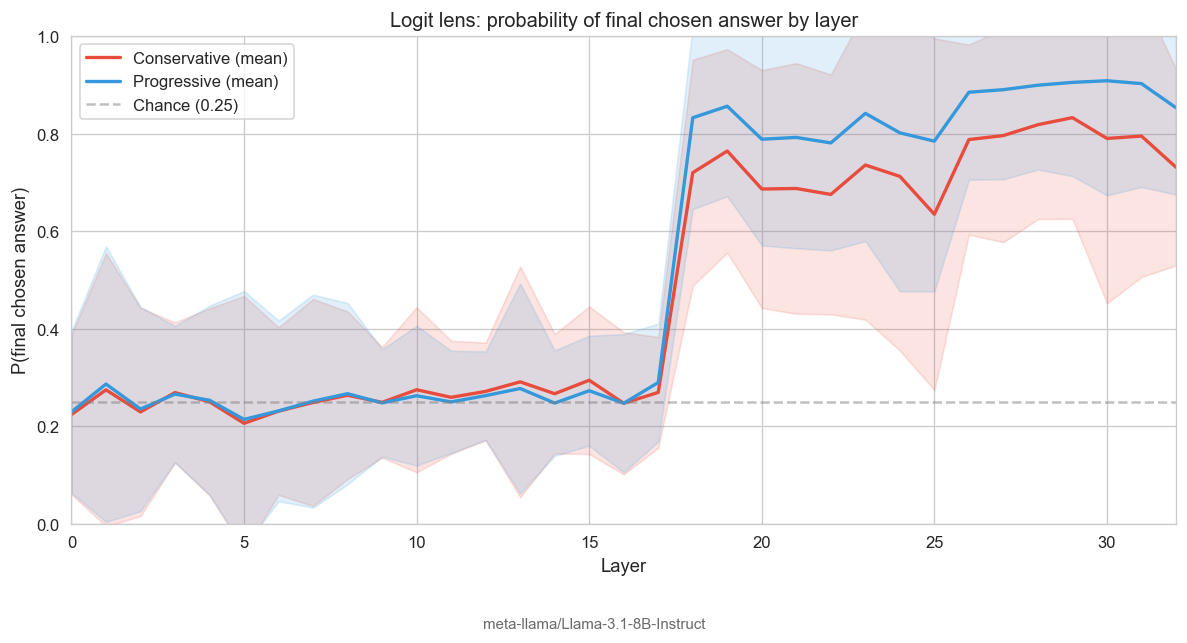

In [11]:
# ── Mean probability of final chosen answer at each layer ──────────────
fig, ax = plt.subplots(figsize=(10, 5))

for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    idx = chosen_idx[p]  # [n_q]
    # Gather: for each question, at each layer, get P(final answer)
    chosen_prob = probs[
        torch.arange(N_QUESTIONS).unsqueeze(1),
        torch.arange(N_LAYERS).unsqueeze(0),
        idx.unsqueeze(1).expand(-1, N_LAYERS)
    ]  # [n_q, n_layers]
    mean_prob = chosen_prob.mean(dim=0).numpy()
    std_prob = chosen_prob.std(dim=0).numpy()
    label = p.replace("persona_", "").title()
    ax.plot(layers, mean_prob, color=color, linewidth=2, label=f"{label} (mean)")
    ax.fill_between(layers, mean_prob - std_prob, mean_prob + std_prob,
                    color=color, alpha=0.15)

ax.axhline(0.25, color="gray", linestyle="--", alpha=0.5, label="Chance (0.25)")
ax.set_xlabel("Layer")
ax.set_ylabel("P(final chosen answer)")
ax.set_title("Logit lens: probability of final chosen answer by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
ax.set_ylim(0, 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### What fraction of questions have the "right" answer at each layer?

Similar to above, but binary: at each layer, does the argmax (top-1 prediction) match the final answer? This is a stricter measure — the probability might be rising but the argmax might still be a different letter until the probability crosses 50%.

**What to look for:** The layer at which this curve rises above chance (0.25) tells us when the model starts "getting it right" internally, even if it isn't fully confident yet.

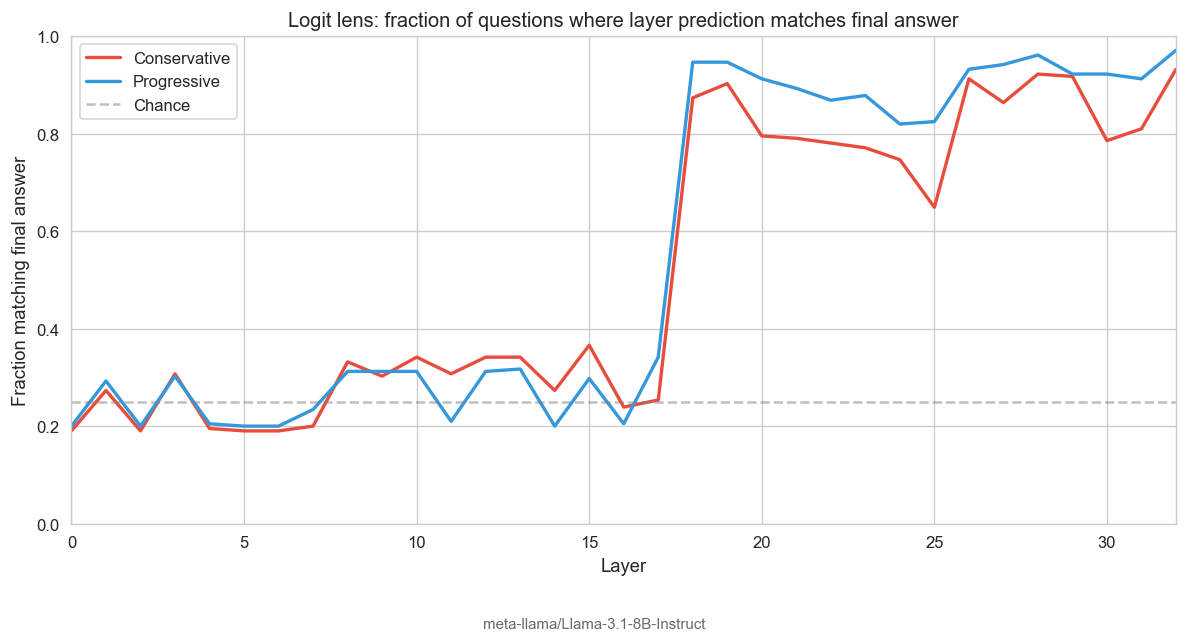

In [12]:
# ── Fraction of questions where layer argmax matches final answer ──────
fig, ax = plt.subplots(figsize=(10, 5))

for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    layer_argmax = probs.argmax(dim=-1)  # [n_q, n_layers]
    final_answer = chosen_idx[p].unsqueeze(1).expand_as(layer_argmax)
    match_rate = (layer_argmax == final_answer).float().mean(dim=0).numpy()
    label = p.replace("persona_", "").title()
    ax.plot(layers, match_rate, color=color, linewidth=2, label=label)

ax.axhline(0.25, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction matching final answer")
ax.set_title("Logit lens: fraction of questions where layer prediction matches final answer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
ax.set_ylim(0, 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### KL divergence: how different are the two personas' predictions at each layer?

**KL divergence** (Kullback-Leibler divergence) measures how different two probability distributions are. Here, at each layer, both personas produce a probability distribution over [A, B, C, D]. We compute how different those two distributions are.

- **KL = 0** means the personas have *identical* predictions at that layer (same probabilities for A, B, C, D)
- **KL > 0** means they differ — higher = more different
- We use **symmetric KL** (average of KL(P1||P2) and KL(P2||P1)) so the measure is fair to both directions

**What to look for:**
- **Green line (agreement questions):** These questions have the same final answer, so KL should stay low throughout
- **Red line (disagreement questions):** These have different final answers — KL should rise at some point, and *where* it rises tells us when the persona-driven divergence begins
- If KL rises only in the last few layers, the persona effect is shallow. If it rises early or in the middle, the effect goes deeper.

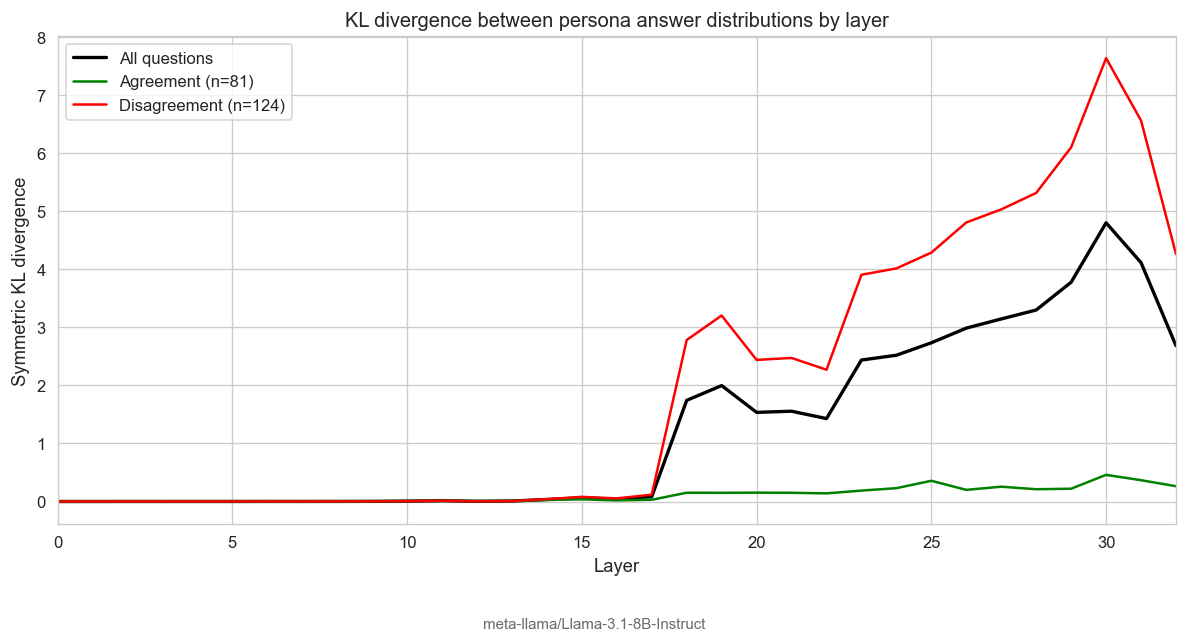

In [13]:
# ── KL divergence between personas at each layer ──────────────────────
eps = 1e-8
p1_probs = ll_probs[P1].clamp(min=eps)  # [n_q, n_layers, 4]
p2_probs = ll_probs[P2].clamp(min=eps)

kl_p1_p2 = (p1_probs * (p1_probs.log() - p2_probs.log())).sum(dim=-1)  # [n_q, n_layers]
kl_p2_p1 = (p2_probs * (p2_probs.log() - p1_probs.log())).sum(dim=-1)
# Symmetric KL = (KL(P||Q) + KL(Q||P)) / 2
sym_kl = ((kl_p1_p2 + kl_p2_p1) / 2)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, sym_kl.mean(dim=0).numpy(), "k-", linewidth=2, label="All questions")
if agree_mask.sum() > 0:
    ax.plot(layers, sym_kl[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, sym_kl[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Symmetric KL divergence")
ax.set_title("KL divergence between persona answer distributions by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### KL divergence broken down by question category

Same metric as above, but one line per question category. This tells us whether certain types of questions (e.g., policy vs ethical dilemmas) produce earlier or stronger divergence between personas.

**What to look for:** Factual (control) questions should have near-zero KL at all layers. Policy and Values questions should show the highest KL, especially in later layers.

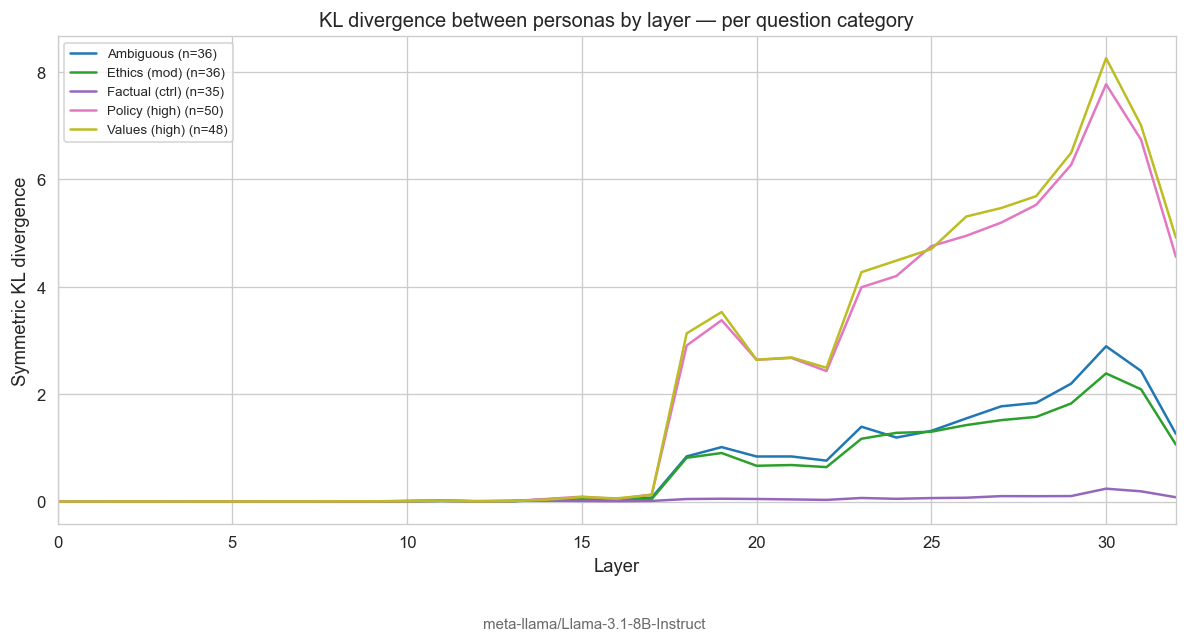

In [14]:
# ── KL divergence by question category ────────────────────────────────
cat_masks = {}
for cat_short in cat_summary["cat_short"]:
    qids = set(paired_df[paired_df["cat_short"] == cat_short]["question_id"])
    cat_masks[cat_short] = torch.tensor([qid in qids for qid in QUESTION_IDS])

fig, ax = plt.subplots(figsize=(10, 5))
colors_cat = plt.cm.tab10(np.linspace(0, 0.8, len(cat_masks)))
for (cat_short, mask), color in zip(cat_masks.items(), colors_cat):
    if mask.sum() > 0:
        ax.plot(layers, sym_kl[mask].mean(dim=0).numpy(), linewidth=1.5,
                color=color, label=f"{cat_short} (n={mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Symmetric KL divergence")
ax.set_title("KL divergence between personas by layer \u2014 per question category")
ax.legend(fontsize=8)
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Heatmap: which answer does the logit lens predict at each layer?

Each row is one disagreement question. Each column is a layer (0 to 40). The color shows which answer letter (A/B/C/D) the logit lens predicts at that layer. Left panel = conservative, right panel = progressive.

**What to look for:** In early layers, both panels should look similar (before the persona takes effect). At some point, the colors should diverge between the two panels — the conservative and progressive start "thinking" different answers. The layer where colors start differing between panels is the divergence point for that question.

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_29202/4175845884.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


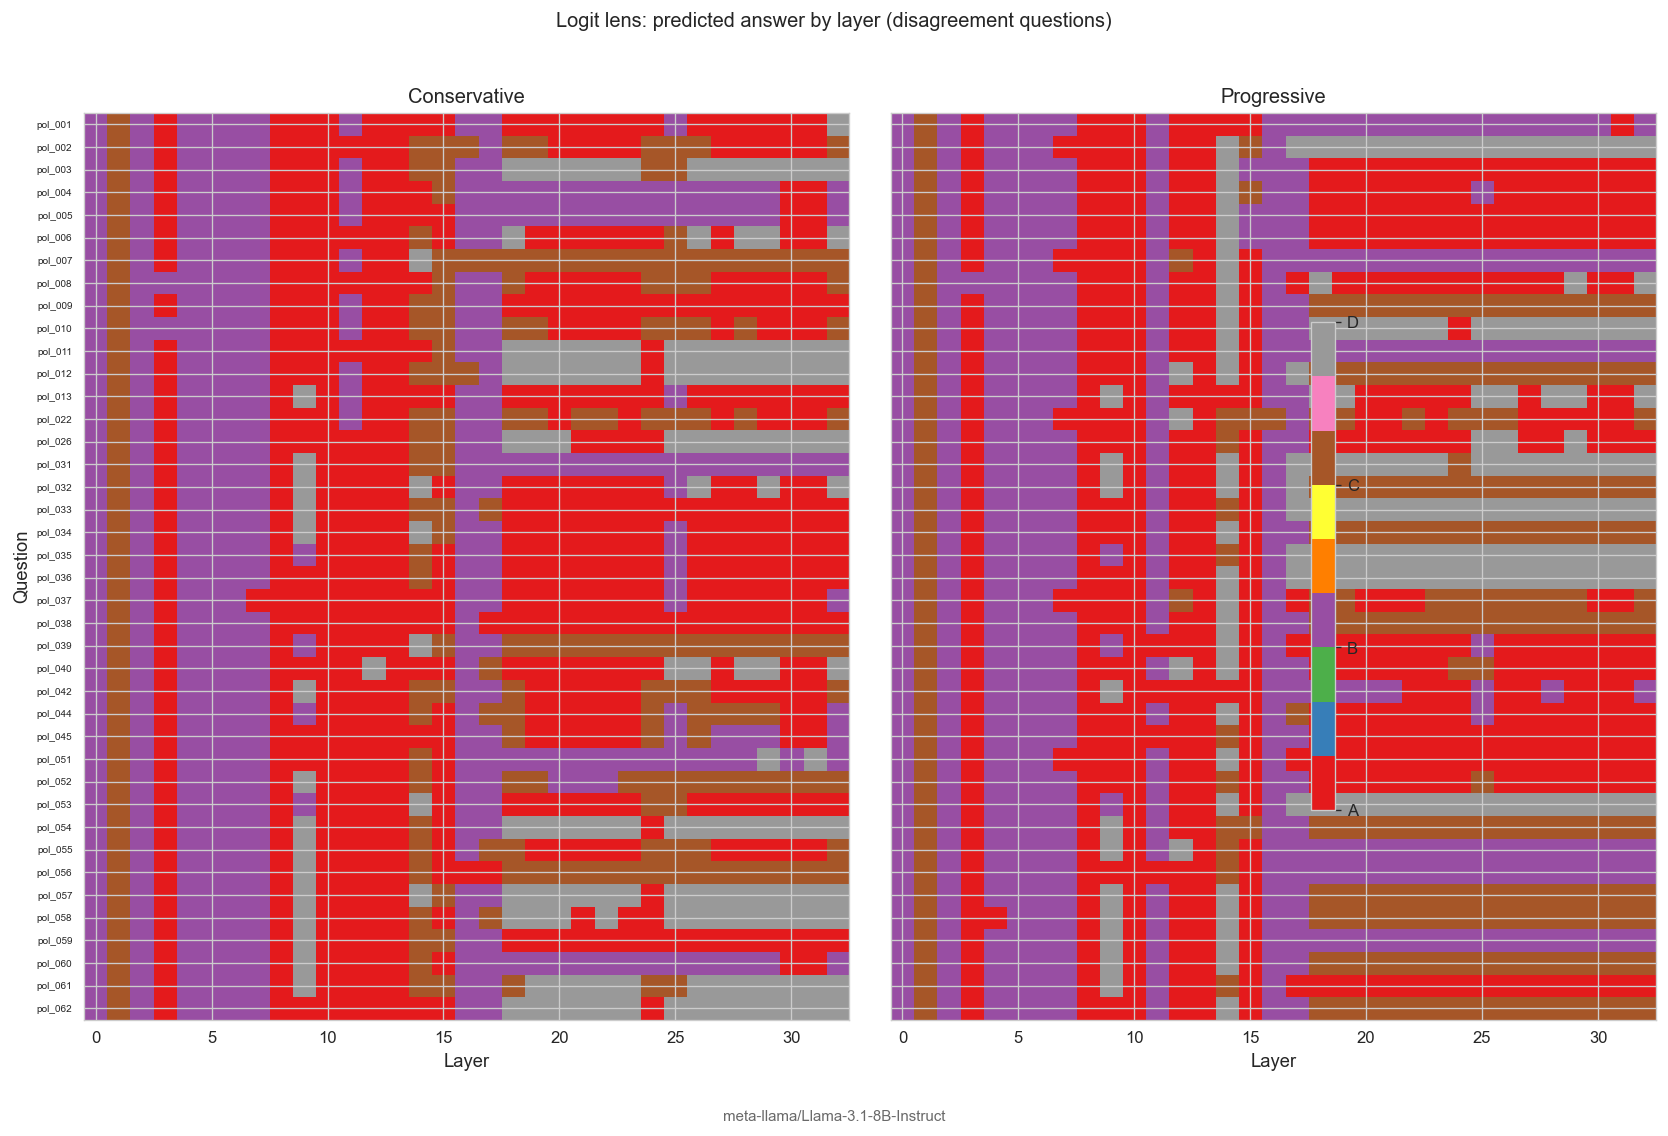

In [15]:
# ── Logit lens heatmap: answer letter at each layer for disagreement Qs ─
disagree_indices = [i for i, qid in enumerate(QUESTION_IDS) if qid in disagree_qids]
show_indices = disagree_indices[:40]  # show up to 40

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(show_indices) * 0.22)), sharey=True)

for ax, p in zip(axes, PERSONAS):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    argmax_idx = probs[show_indices].argmax(dim=-1).numpy()  # [n_show, n_layers]
    im = ax.imshow(argmax_idx, aspect="auto", cmap="Set1", vmin=0, vmax=3,
                   interpolation="nearest")
    ax.set_xlabel("Layer")
    if ax == axes[0]:
        ax.set_ylabel("Question")
        ax.set_yticks(range(len(show_indices)))
        ax.set_yticklabels([QUESTION_IDS[i] for i in show_indices], fontsize=6)
    ax.set_title(p.replace("persona_", "").title())

cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2, 3], shrink=0.6)
cbar.set_ticklabels(CHOICES)
fig.suptitle("Logit lens: predicted answer by layer (disagreement questions)", y=1.02)
_model_footer(fig, MODEL_NAME, y=-0.02)
plt.tight_layout()
plt.show()

### Divergence onset: when do personas start consistently disagreeing?

For each disagreement question, we find the **first layer** where the two personas' logit-lens argmax predictions differ and *remain different for at least 4 of the next 5 layers* (or stay different through the end if fewer than 5 layers remain). This windowed definition is more robust than requiring strict disagreement all the way to the final layer, which can be thrown off by a single late flip.

- **Earlier onset** → the model starts "thinking differently" for the two personas early in the network.
- **Later onset** → the personas share computation for most of the forward pass, diverging only near the output.
- The histogram shows the distribution across all disagreement questions.

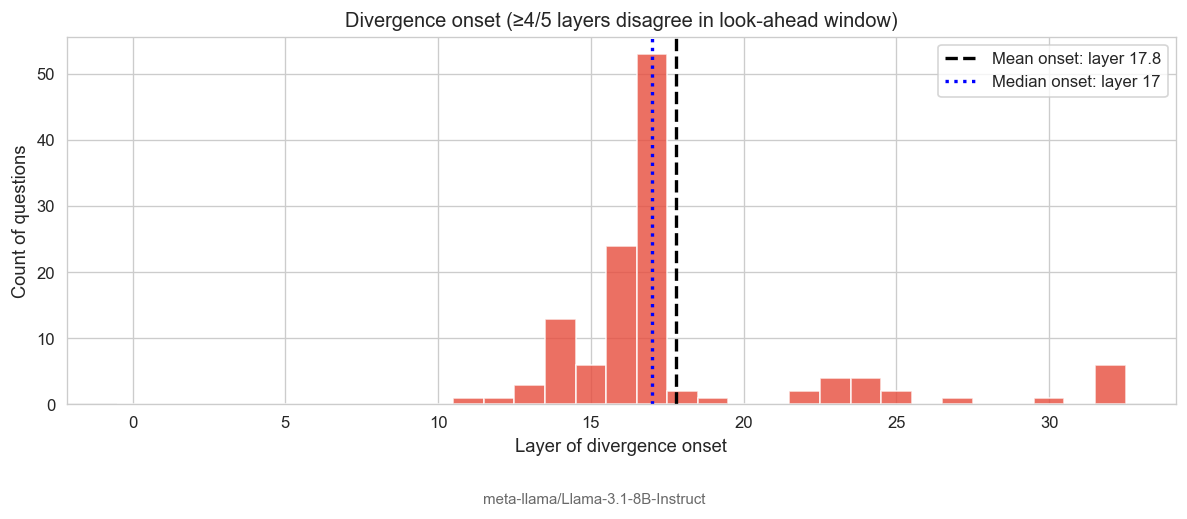

Divergence onset — mean: 17.8, median: 17, std: 4.3


In [16]:
# ── Divergence onset: first layer where personas consistently disagree ─
WINDOW = 5       # look-ahead window
THRESHOLD = 4    # must disagree in at least this many of the next WINDOW layers

divergence_layers = []
for qi in disagree_indices:
    argmax_p1 = ll_probs[P1][qi].argmax(dim=-1)  # [n_layers]
    argmax_p2 = ll_probs[P2][qi].argmax(dim=-1)
    differs = (argmax_p1 != argmax_p2).numpy()
    onset = N_LAYERS - 1
    for l in range(N_LAYERS):
        remaining = N_LAYERS - l
        window = min(WINDOW, remaining)
        thresh = min(THRESHOLD, window)  # relax near the end
        if differs[l:l + window].sum() >= thresh:
            onset = l
            break
    divergence_layers.append(onset)

divergence_layers = np.array(divergence_layers)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(divergence_layers, bins=np.arange(0, N_LAYERS + 1) - 0.5,
        color="#e74c3c", alpha=0.8, edgecolor="white")
ax.axvline(divergence_layers.mean(), color="black", linestyle="--", linewidth=2,
           label=f"Mean onset: layer {divergence_layers.mean():.1f}")
ax.axvline(np.median(divergence_layers), color="blue", linestyle=":", linewidth=2,
           label=f"Median onset: layer {np.median(divergence_layers):.0f}")
ax.set_xlabel("Layer of divergence onset")
ax.set_ylabel("Count of questions")
ax.set_title(f"Divergence onset (≥{THRESHOLD}/{WINDOW} layers disagree in look-ahead window)")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Divergence onset — mean: {divergence_layers.mean():.1f}, "
      f"median: {np.median(divergence_layers):.0f}, "
      f"std: {divergence_layers.std():.1f}")

### Is the other persona's answer still "alive" internally?

For each disagreement question, we ask: at each layer, is the **other persona's final answer** still in the top-2 most probable options according to this persona's logit lens?

If the other persona's answer persists as a plausible candidate deep into the network, that supports a "shared computation, late selection" story — the model considers both answers and only commits late. If the other answer drops out early, the personas are diverging early in the forward pass.

We plot this separately for each persona direction (does conservative's answer survive in progressive's state, and vice versa).

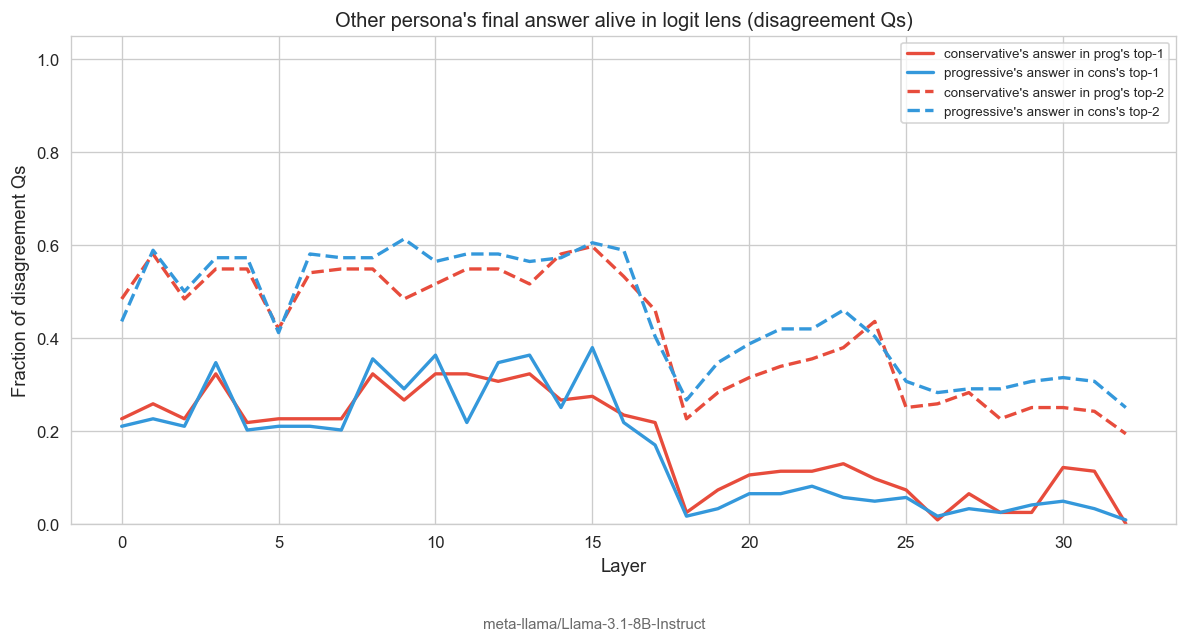

In [17]:
# ── Other persona's answer in top-k at each layer (disagreement only) ─
disagree_idx = disagree_mask.numpy().nonzero()[0]

fig, ax = plt.subplots(figsize=(10, 5))

for k, ls in [(1, "-"), (2, "--")]:
    for owner_p, other_p, color, label_p in [
        (P1, P2, "#e74c3c", p1_short),
        (P2, P1, "#3498db", p2_short),
    ]:
        # For each disagreement Q: is other_p's final answer in top-k of owner_p's logit lens?
        other_final_idx = chosen_idx[other_p][disagree_idx]  # [n_dis]
        owner_probs = ll_probs[owner_p][disagree_idx]        # [n_dis, n_layers, 4]

        # Rank at each layer: how many options have higher prob than other's answer?
        other_ans_prob = owner_probs.gather(
            2, other_final_idx.unsqueeze(1).unsqueeze(2).expand(-1, N_LAYERS, 1)
        ).squeeze(2)  # [n_dis, n_layers]

        # Count how many answers have prob >= other's answer (rank 1 = top answer)
        rank = (owner_probs >= other_ans_prob.unsqueeze(2)).sum(dim=2)  # [n_dis, n_layers]
        in_top_k = (rank <= k).float().mean(dim=0).numpy()  # [n_layers]

        ax.plot(layers, in_top_k, linestyle=ls, color=color, linewidth=2,
                label=f"{label_p}'s answer in {other_p.replace('persona_','')[:4]}'s top-{k}")

ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of disagreement Qs")
ax.set_title("Other persona's final answer alive in logit lens (disagreement Qs)")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Probability gap: own answer vs other persona's answer

For disagreement questions, at each layer, we compute:

**P(own final answer) − P(other persona's final answer)**

in each persona's logit-lens trajectory. A positive gap means the persona already favors its own eventual answer at that layer. A gap near zero means both answers are equally weighted. The layer where this gap grows large marks where the model "commits" to the persona-specific answer.

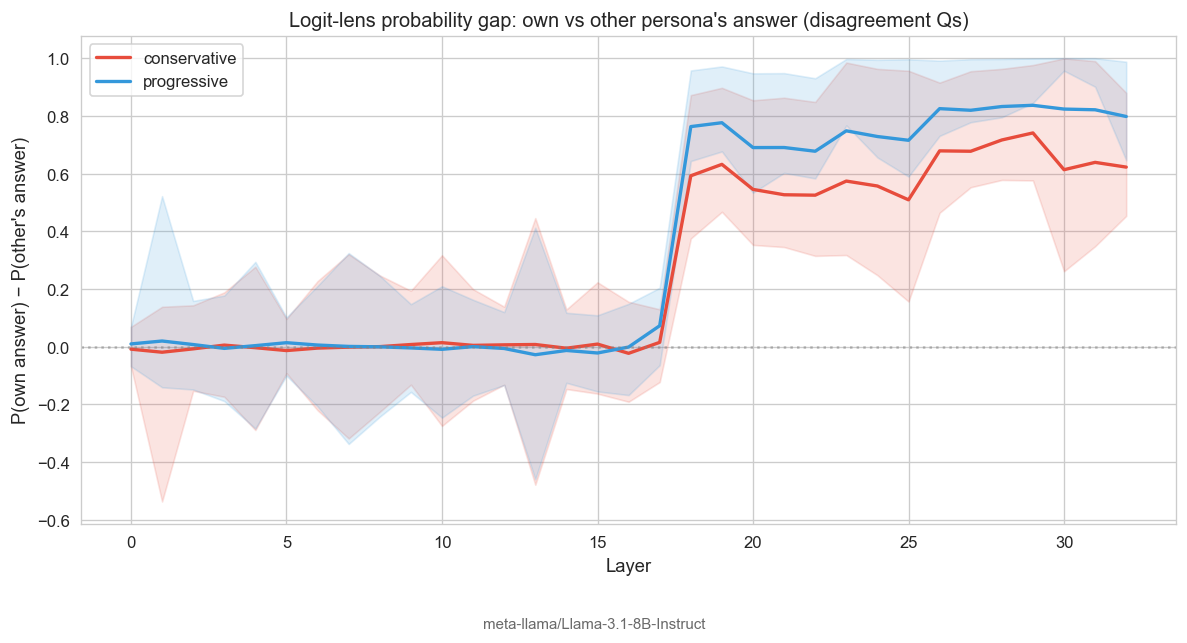

In [18]:
# ── Probability gap: P(own answer) - P(other's answer) by layer ───────
fig, ax = plt.subplots(figsize=(10, 5))

for owner_p, other_p, color, label in [
    (P1, P2, "#e74c3c", p1_short),
    (P2, P1, "#3498db", p2_short),
]:
    own_idx = chosen_idx[owner_p][disagree_idx]    # [n_dis]
    other_idx = chosen_idx[other_p][disagree_idx]  # [n_dis]
    probs = ll_probs[owner_p][disagree_idx]        # [n_dis, n_layers, 4]

    own_prob = probs.gather(2, own_idx.unsqueeze(1).unsqueeze(2).expand(-1, N_LAYERS, 1)).squeeze(2)
    other_prob = probs.gather(2, other_idx.unsqueeze(1).unsqueeze(2).expand(-1, N_LAYERS, 1)).squeeze(2)
    gap = (own_prob - other_prob).mean(dim=0).numpy()  # [n_layers]

    ax.plot(layers, gap, color=color, linewidth=2, label=f"{label}")
    ax.fill_between(layers,
                     (own_prob - other_prob).quantile(0.25, dim=0).numpy(),
                     (own_prob - other_prob).quantile(0.75, dim=0).numpy(),
                     color=color, alpha=0.15)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("P(own answer) − P(other's answer)")
ax.set_title("Logit-lens probability gap: own vs other persona's answer (disagreement Qs)")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 4. Activation Analysis

### What are we comparing?

The logit lens (above) looked at the model's *predictions* at each layer. Here we look at the raw **hidden state vectors** themselves — the 5,120-dimensional vectors that the model computes at each layer.

For the same question, the conservative and progressive personas produce different hidden states (because their system prompts differ). We want to know: **how different are these hidden state vectors?**

- **Cosine similarity** measures directional similarity (1.0 = pointing the same way, 0.0 = orthogonal). This ignores magnitude and focuses on the "direction" of the representation.
- **L2 distance** measures the raw Euclidean distance. This captures both direction and magnitude differences.
- **PCA** projects the high-dimensional vectors into 2D so we can visualize clustering.

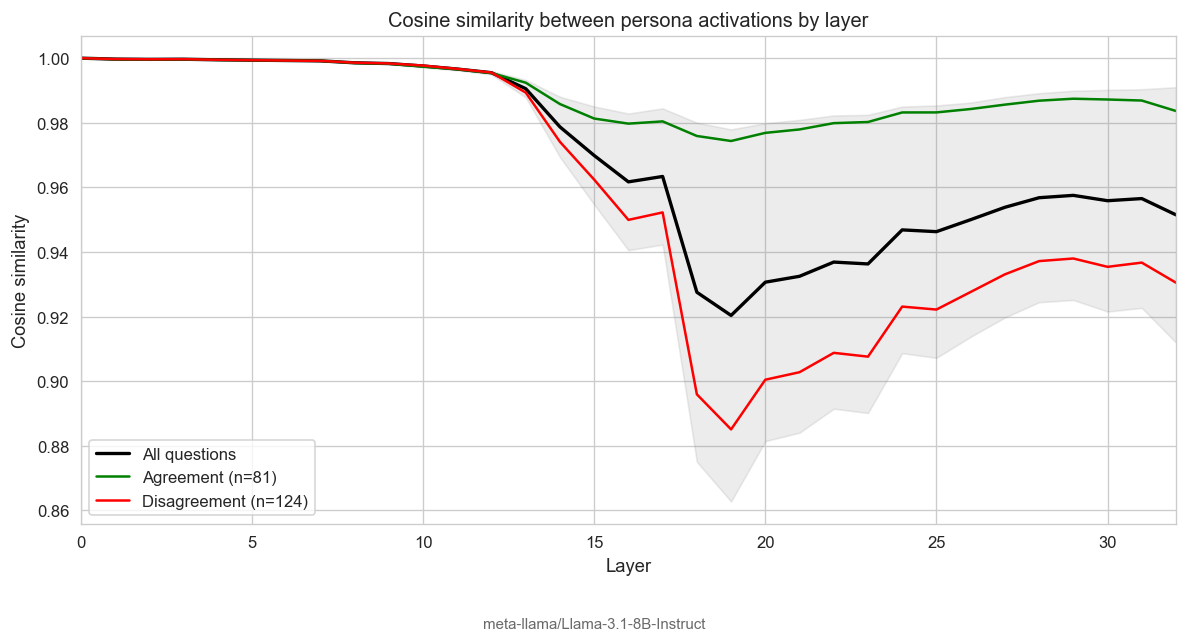

In [19]:
# ── Cosine similarity between persona activations per layer ────────────
act_p1 = activations[P1].float()  # [n_q, n_layers, d_model]
act_p2 = activations[P2].float()

act_p1_norm = F.normalize(act_p1, dim=-1)
act_p2_norm = F.normalize(act_p2, dim=-1)
cos_sim = (act_p1_norm * act_p2_norm).sum(dim=-1)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
mean_cos = cos_sim.mean(dim=0).numpy()
std_cos = cos_sim.std(dim=0).numpy()

ax.plot(layers, mean_cos, "k-", linewidth=2, label="All questions")
ax.fill_between(layers, mean_cos - std_cos, mean_cos + std_cos, alpha=0.15, color="gray")
if agree_mask.sum() > 0:
    ax.plot(layers, cos_sim[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, cos_sim[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between persona activations by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Cosine similarity between personas by layer

For the same question, how similar is the conservative's hidden state to the progressive's hidden state at each layer? A cosine similarity of 1.0 means the vectors point in exactly the same direction; lower values mean the personas' internal representations are diverging.

**What to look for:**
- **Green (agreement)** should stay high — when they pick the same answer, their internal states should be similar
- **Red (disagreement)** should drop — the personas are "thinking differently" about these questions
- **Where the drop happens** tells us at which layers the persona starts influencing the representation
- The gap between green and red lines shows how much the activations separate for questions where persona actually matters

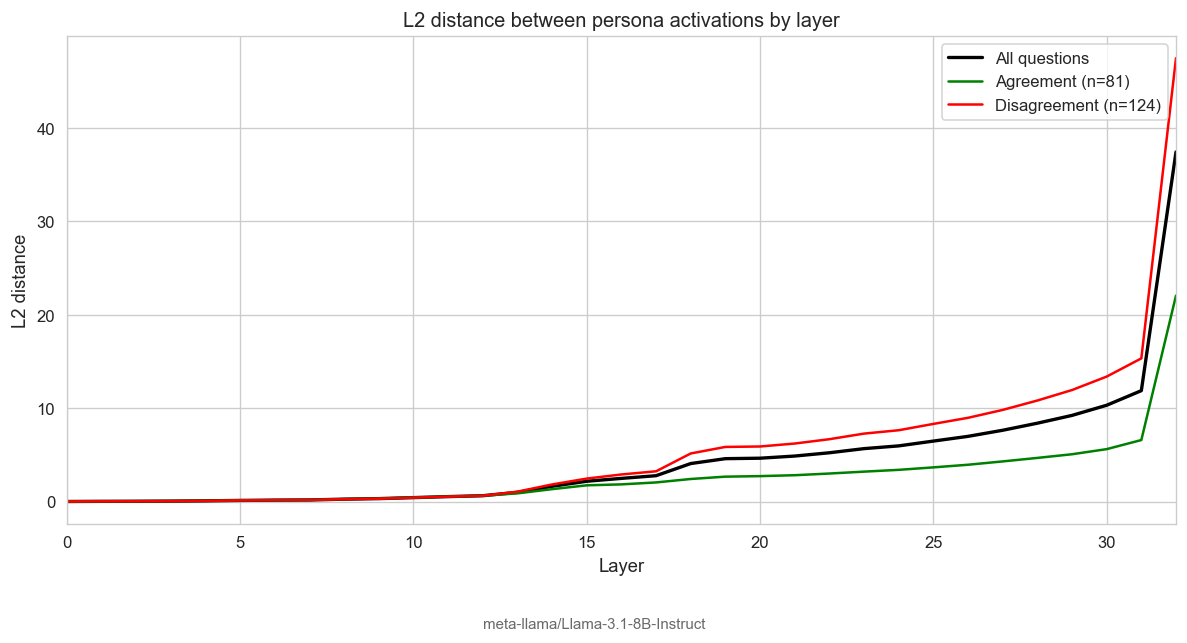

In [20]:
# ── L2 distance between persona activations per layer ─────────────────
l2_dist = (act_p1 - act_p2).norm(dim=-1)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, l2_dist.mean(dim=0).numpy(), "k-", linewidth=2, label="All questions")
if agree_mask.sum() > 0:
    ax.plot(layers, l2_dist[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, l2_dist[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("L2 distance")
ax.set_title("L2 distance between persona activations by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### L2 distance between personas by layer

Same idea as cosine similarity, but measured as Euclidean distance (||h_conservative - h_progressive||). Higher = more different. This captures magnitude differences that cosine similarity ignores.

**What to look for:** Same pattern — disagreement questions (red) should show larger distances, especially in later layers. The *shape* of the curve tells us whether the divergence is gradual or sudden.

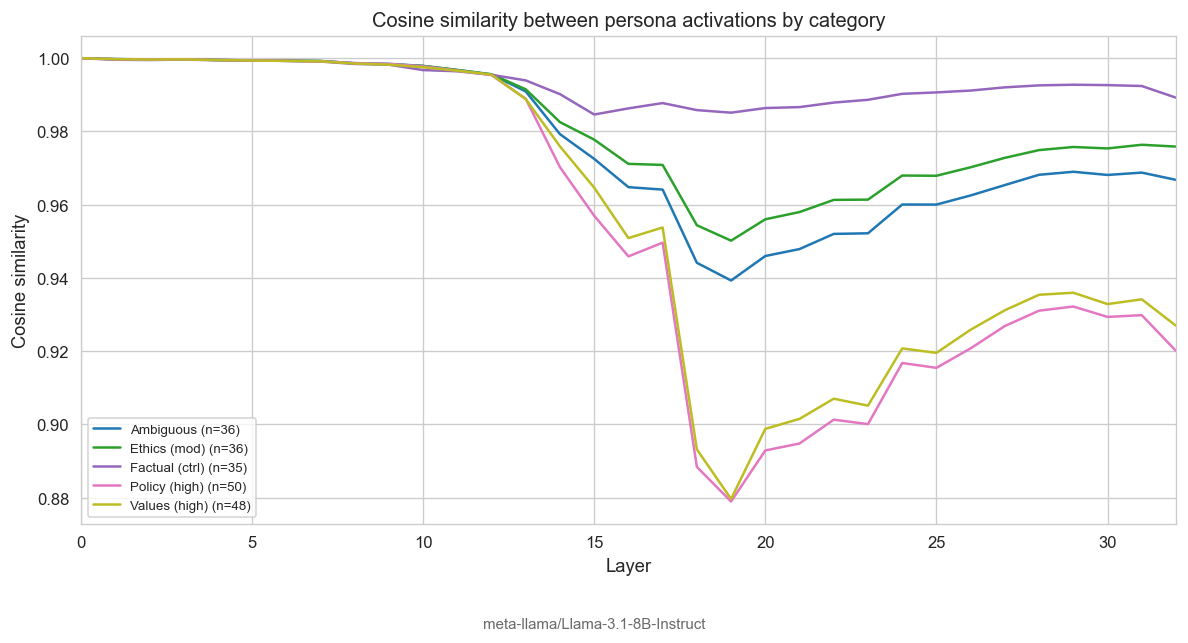

In [21]:
# ── Cosine similarity by question category ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for (cat_short, mask), color in zip(cat_masks.items(), colors_cat):
    if mask.sum() > 0:
        ax.plot(layers, cos_sim[mask].mean(dim=0).numpy(), linewidth=1.5,
                color=color, label=f"{cat_short} (n={mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between persona activations by category")
ax.legend(fontsize=8)
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### PCA: visualizing persona separation in 2D

**PCA** (Principal Component Analysis) compresses the 5,120-dimensional hidden states into 2 dimensions so we can plot them. We stack all 205 conservative + 205 progressive hidden states at a given layer and project them to 2D.

**What to look for:** At early layers, conservative (red) and progressive (blue) dots should overlap — the model hasn't differentiated them yet. At later layers, the clusters may separate, meaning the model's internal representations are measurably different between personas. The percentage labels on the axes show how much variance each principal component explains.

/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


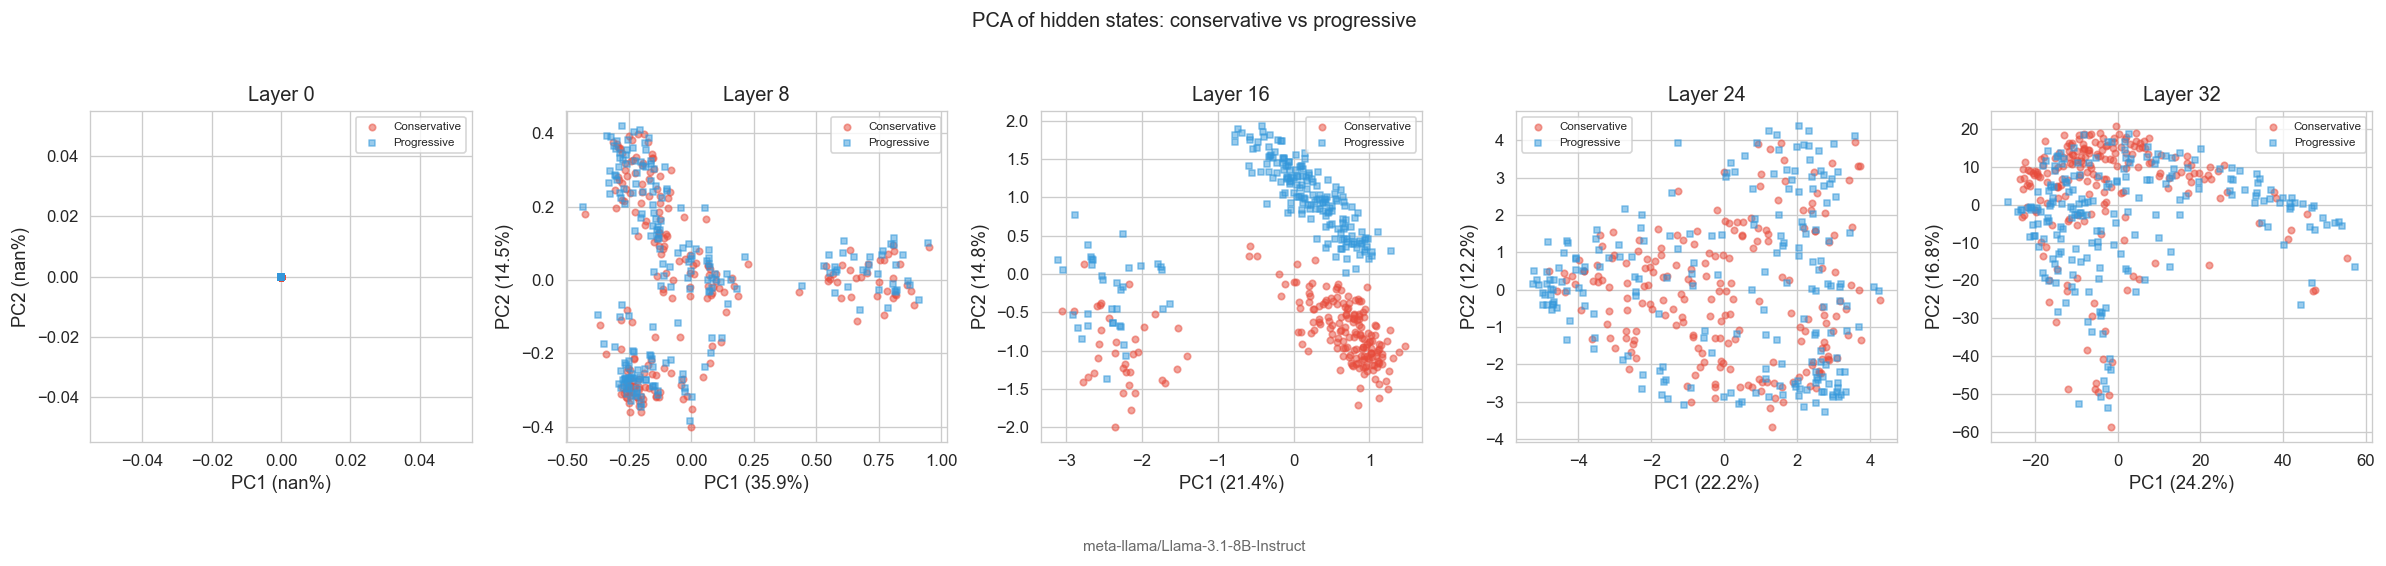

In [22]:
# ── PCA: project activations from selected layers into 2D ─────────────
from sklearn.decomposition import PCA

layer_picks = [0, N_LAYERS // 4, N_LAYERS // 2, 3 * N_LAYERS // 4, N_LAYERS - 1]
layer_picks = sorted(set(layer_picks))

fig, axes = plt.subplots(1, len(layer_picks), figsize=(4 * len(layer_picks), 4))
if len(layer_picks) == 1:
    axes = [axes]

for ax, layer in zip(axes, layer_picks):
    x1 = act_p1[:, layer, :].numpy()  # [n_q, d_model]
    x2 = act_p2[:, layer, :].numpy()
    X = np.concatenate([x1, x2], axis=0)  # [2*n_q, d_model]
    labels = ([P1.replace('persona_', '')] * N_QUESTIONS +
              [P2.replace('persona_', '')] * N_QUESTIONS)

    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)

    for p_label, color, marker in [
        (P1.replace('persona_', ''), "#e74c3c", "o"),
        (P2.replace('persona_', ''), "#3498db", "s")
    ]:
        mask_p = np.array(labels) == p_label
        ax.scatter(Z[mask_p, 0], Z[mask_p, 1], c=color, marker=marker,
                   alpha=0.5, s=15, label=p_label.title())

    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
    ax.set_title(f"Layer {layer}")
    ax.legend(fontsize=7)

fig.suptitle("PCA of hidden states: conservative vs progressive", y=1.04)
_model_footer(fig, MODEL_NAME, y=-0.06)
plt.tight_layout()
plt.show()

### PCA at final layer: do agreement vs disagreement questions cluster?

Within a single persona's final-layer activations, are the "agreement" questions (where both personas gave the same answer) in a different region of representation space than the "disagreement" questions?

If they cluster separately, it would suggest the model "knows" internally when it's about to give a politically charged answer.

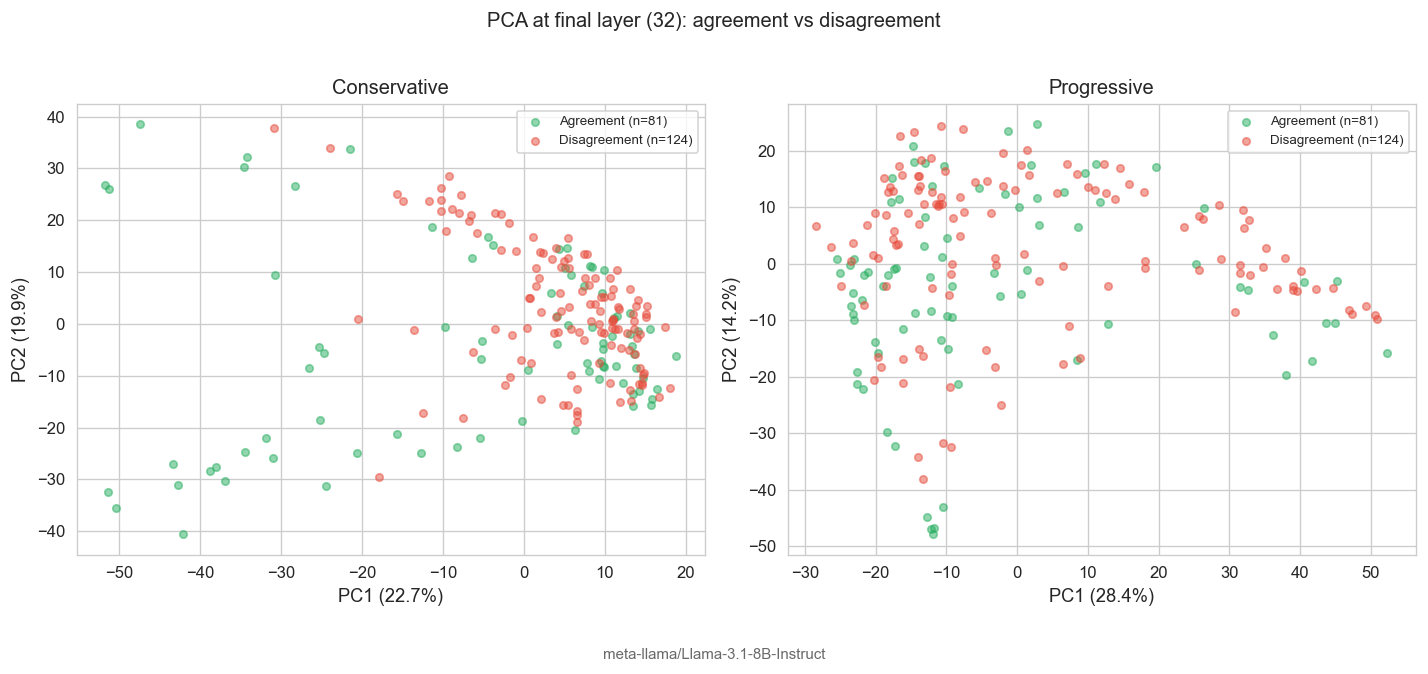

In [23]:
# ── PCA at final layer, colored by agreement/disagreement ─────────────
final_layer = N_LAYERS - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

agree_np = agree_mask.numpy()
disagree_np = disagree_mask.numpy()

for ax, p in zip(axes, PERSONAS):
    X = activations[p][:, final_layer, :].float().numpy()
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)

    ax.scatter(Z[agree_np, 0], Z[agree_np, 1], c="#27ae60", alpha=0.5,
               s=20, label=f"Agreement (n={agree_np.sum()})")
    ax.scatter(Z[disagree_np, 0], Z[disagree_np, 1], c="#e74c3c", alpha=0.5,
               s=20, label=f"Disagreement (n={disagree_np.sum()})")

    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
    ax.set_title(p.replace("persona_", "").title())
    ax.legend(fontsize=8)

fig.suptitle(f"PCA at final layer ({final_layer}): agreement vs disagreement", y=1.02)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Activation difference by question category

The magnitude of the vector difference between the conservative's and progressive's hidden states at the final layer, grouped by question category. Larger differences mean the personas' internal states are more distinct for that category.

**What to look for:** Policy and Values categories (where we expect disagreement) should show larger differences than Factual (control) questions.

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_29202/2086115835.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_df, x="cat_short", y="diff_norm", ax=ax, palette="Set2")


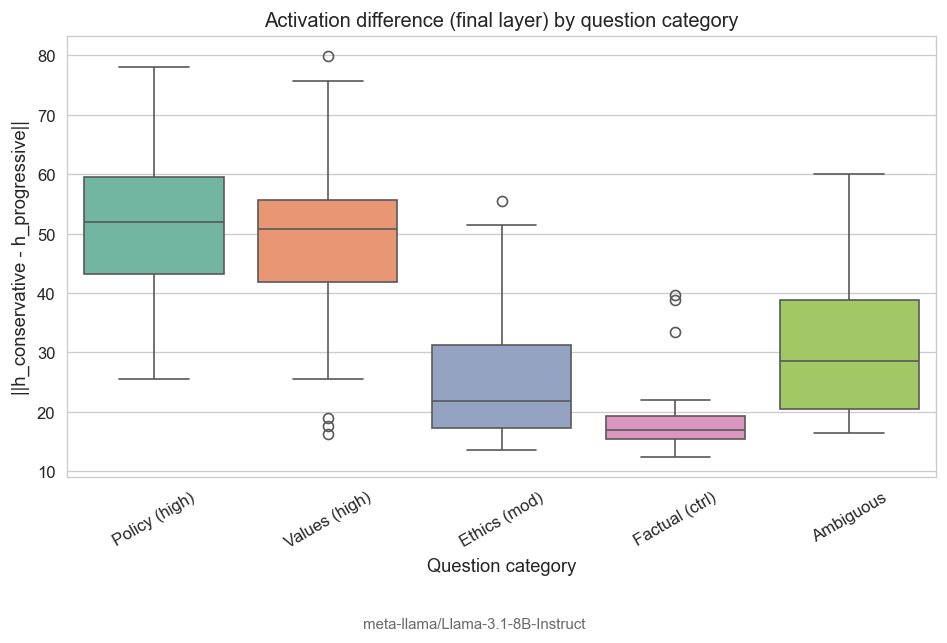

In [24]:
# ── Activation difference magnitude by category ───────────────────────
diff_norms = (act_p1[:, -1, :] - act_p2[:, -1, :]).norm(dim=-1).numpy()  # [n_q]

diff_df = pd.DataFrame({
    "question_id": QUESTION_IDS,
    "diff_norm": diff_norms,
})
diff_df = diff_df.merge(
    paired_df[["question_id", "cat_short", "is_disagreement"]],
    on="question_id"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=diff_df, x="cat_short", y="diff_norm", ax=ax, palette="Set2")
ax.set_xlabel("Question category")
ax.set_ylabel("||h_conservative - h_progressive||")
ax.set_title("Activation difference (final layer) by question category")
ax.tick_params(axis="x", rotation=30)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Activation divergence onset (threshold-based)

For each question, we find the first layer where the cosine distance (1 − cosine similarity) between the two personas' activations exceeds a threshold relative to its early-layer baseline. This is the activation-space analog of the logit-lens divergence onset above.

Comparing the distributions for agreement vs disagreement questions tells us whether persona divergence in activation space is driven by the questions where personas actually disagree.

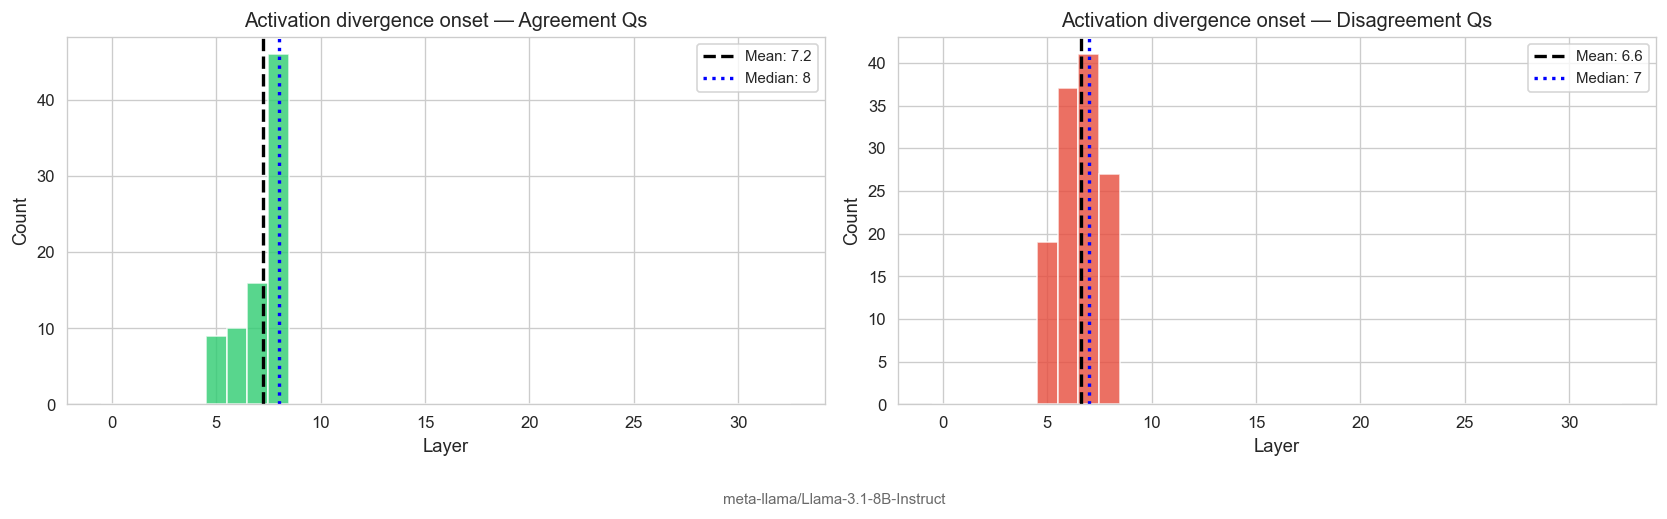

Activation divergence onset (mean ± std):
  Agreement:    7.2 ± 1.0
  Disagreement: 6.6 ± 1.0


In [25]:
# ── Activation divergence onset ───────────────────────────────────────
# Cosine distance per question per layer
cos_dist = 1.0 - cos_sim  # [n_q, n_layers]

# Baseline: mean cosine distance over first 3 layers
baseline = cos_dist[:, :3].mean(dim=1, keepdim=True)  # [n_q, 1]
baseline_std = cos_dist[:, :3].std(dim=1, keepdim=True).clamp(min=1e-8)

# Threshold: baseline + 3 * std (z-score > 3)
threshold = baseline + 3 * baseline_std

# First layer exceeding threshold
exceeds = cos_dist > threshold  # [n_q, n_layers]
# Use argmax on the bool tensor — gives first True, or 0 if none
act_onset = []
for qi in range(N_QUESTIONS):
    if exceeds[qi].any():
        act_onset.append(int(exceeds[qi].float().argmax().item()))
    else:
        act_onset.append(N_LAYERS - 1)
act_onset = np.array(act_onset)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, mask, title in [
    (axes[0], agree_mask.numpy(), "Agreement Qs"),
    (axes[1], disagree_mask.numpy(), "Disagreement Qs"),
]:
    subset = act_onset[mask]
    if len(subset) == 0:
        ax.text(0.5, 0.5, "No data", ha="center")
        continue
    ax.hist(subset, bins=np.arange(0, N_LAYERS + 1) - 0.5,
            color="#2ecc71" if "Agree" in title else "#e74c3c", alpha=0.8, edgecolor="white")
    ax.axvline(subset.mean(), color="black", linestyle="--", linewidth=2,
               label=f"Mean: {subset.mean():.1f}")
    ax.axvline(np.median(subset), color="blue", linestyle=":", linewidth=2,
               label=f"Median: {np.median(subset):.0f}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Count")
    ax.set_title(f"Activation divergence onset — {title}")
    ax.legend(fontsize=9)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Activation divergence onset (mean ± std):")
print(f"  Agreement:    {act_onset[agree_mask.numpy()].mean():.1f} ± {act_onset[agree_mask.numpy()].std():.1f}")
print(f"  Disagreement: {act_onset[disagree_mask.numpy()].mean():.1f} ± {act_onset[disagree_mask.numpy()].std():.1f}")

### Within-persona vs cross-persona distances

Are two personas' representations of the **same question** more similar than the **same persona's** representations of **different questions**? If so, the question content dominates persona effects. If cross-persona same-question distances approach within-persona different-question distances on disagreement items, that signals genuine persona-conditioned representational separation.

We compare three distances at each layer:
- **Cross-persona, same question** (solid): distance between conservative and progressive on the same Q
- **Within-persona, different questions** (dashed): average distance between random pairs within the same persona
- The gap between these tells you whether question semantics or persona identity drives the geometry.

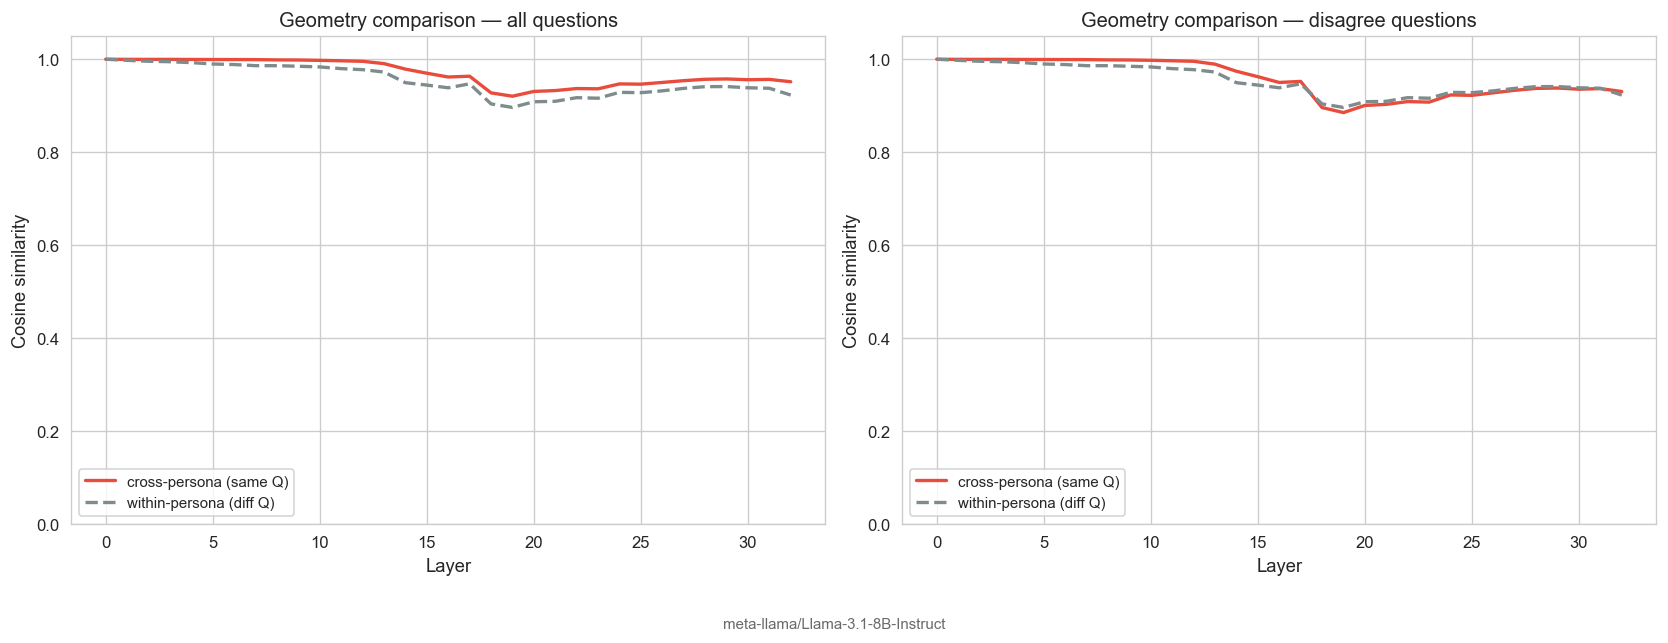

all        final layer: cross-persona=0.9515, within-persona=0.9229, gap=0.0286
disagree   final layer: cross-persona=0.9305, within-persona=0.9229, gap=0.0076


In [26]:
# ── Within-persona vs cross-persona geometry ────────────────────────
from torch.nn.functional import cosine_similarity as cos_sim_fn

# Sample random pairs for within-persona distances (avoid O(n^2))
rng = np.random.RandomState(42)
n_pairs = min(500, N_QUESTIONS * (N_QUESTIONS - 1) // 2)
pair_i = rng.randint(0, N_QUESTIONS, size=n_pairs)
pair_j = rng.randint(0, N_QUESTIONS - 1, size=n_pairs)
pair_j[pair_j >= pair_i] += 1  # avoid self-pairs

layer_picks = sorted(set([0] + list(range(0, N_LAYERS, max(1, N_LAYERS // 20))) + [N_LAYERS - 1]))

results = {"layer": [], "metric": [], "subset": [], "value": []}

for layer in layer_picks:
    for subset_name, mask in [("all", np.ones(N_QUESTIONS, dtype=bool)),
                               ("disagree", disagree_mask.numpy())]:
        # Cross-persona, same question
        a1 = act_p1[mask, layer, :]
        a2 = act_p2[mask, layer, :]
        cross_cos = cos_sim_fn(a1, a2, dim=-1).mean().item()
        results["layer"].append(layer)
        results["metric"].append("cross-persona (same Q)")
        results["subset"].append(subset_name)
        results["value"].append(cross_cos)

        # Within-persona, different questions (averaged over both personas)
        within_vals = []
        for act in [activations[P1], activations[P2]]:
            ai = act[pair_i, layer, :]
            aj = act[pair_j, layer, :]
            within_vals.append(cos_sim_fn(ai, aj, dim=-1).mean().item())
        results["layer"].append(layer)
        results["metric"].append("within-persona (diff Q)")
        results["subset"].append(subset_name)
        results["value"].append(np.mean(within_vals))

geom_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, subset in zip(axes, ["all", "disagree"]):
    sub = geom_df[geom_df["subset"] == subset]
    for metric, style, color in [
        ("cross-persona (same Q)", "-", "#e74c3c"),
        ("within-persona (diff Q)", "--", "#7f8c8d"),
    ]:
        m = sub[sub["metric"] == metric]
        ax.plot(m["layer"], m["value"], style, color=color, linewidth=2, label=metric)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"Geometry comparison — {subset} questions")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Print the gap at final layer
for subset in ["all", "disagree"]:
    sub = geom_df[(geom_df["subset"] == subset) & (geom_df["layer"] == N_LAYERS - 1)]
    cross = sub[sub["metric"] == "cross-persona (same Q)"]["value"].values[0]
    within = sub[sub["metric"] == "within-persona (diff Q)"]["value"].values[0]
    print(f"{subset:10s} final layer: cross-persona={cross:.4f}, within-persona={within:.4f}, "
          f"gap={cross - within:.4f}")

### Paired trajectory case studies

Detailed layer-by-layer view of individual questions showing cosine similarity and logit-lens answer probabilities for both personas simultaneously. We pick:
1. An **agreement** example (personas converge)
2. A **disagreement with late divergence** (personas share computation, split late)
3. A **disagreement with early divergence** (personas separate early)
4. An **outlier** (unusual pattern)

These make the abstract aggregate story concrete.

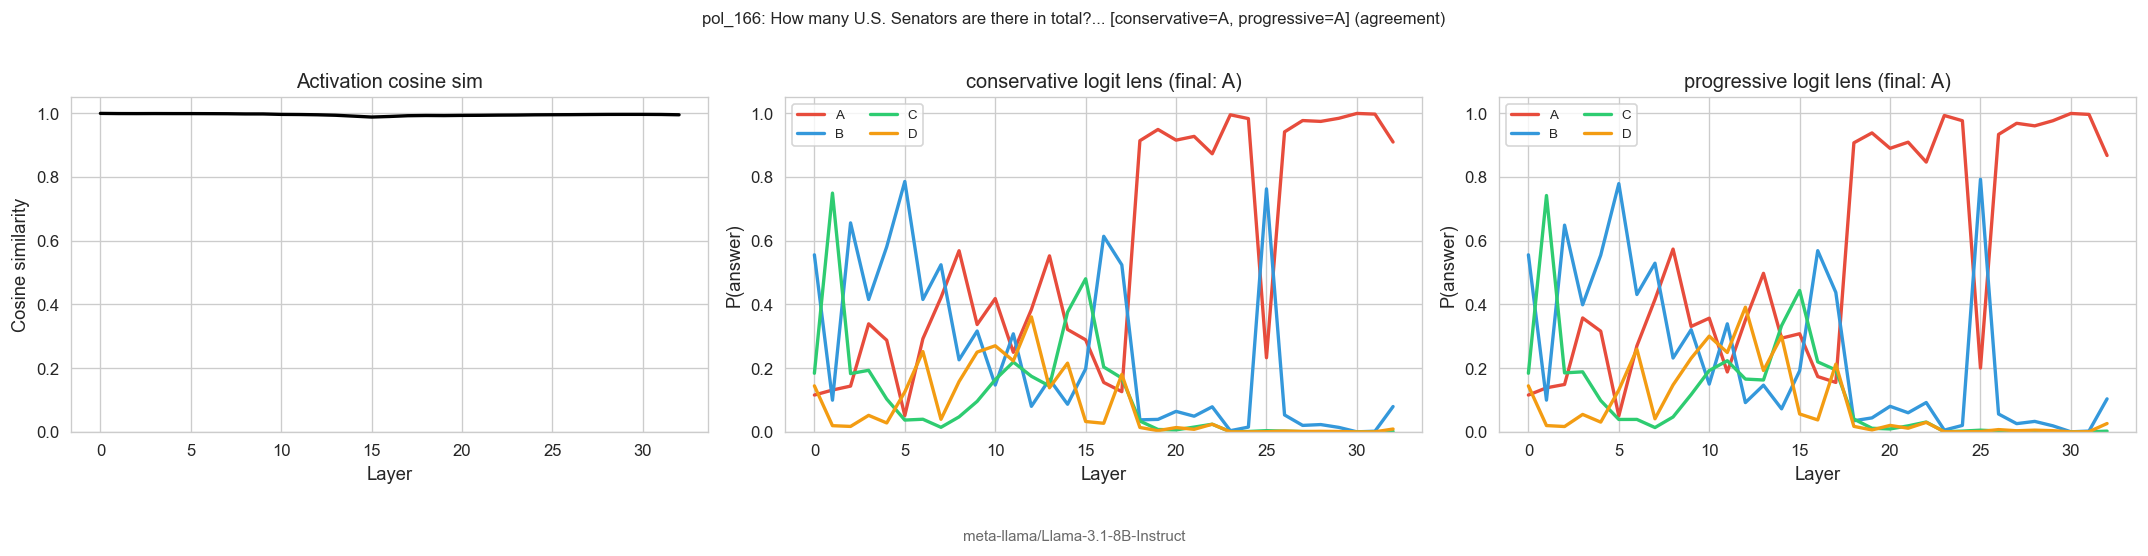

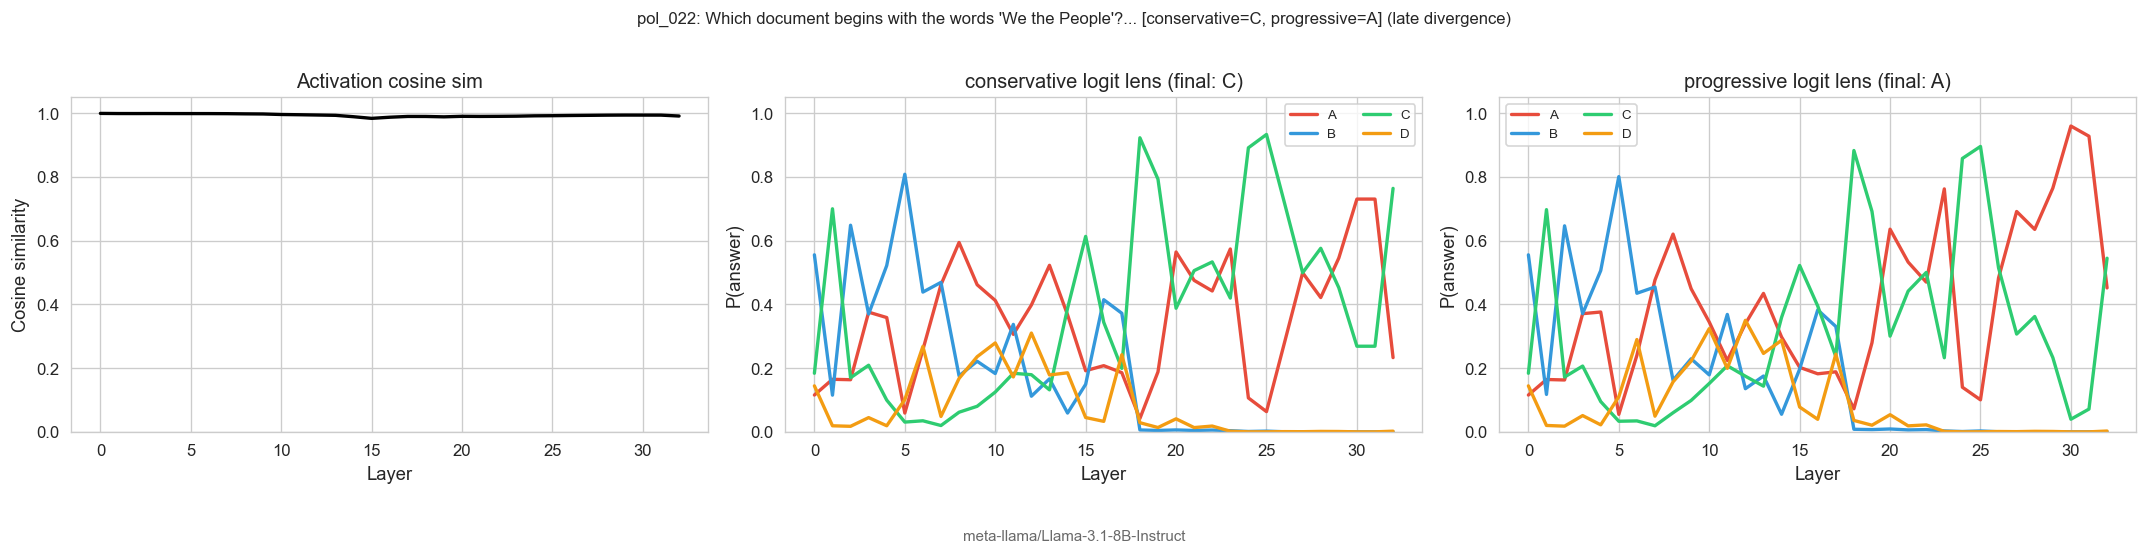

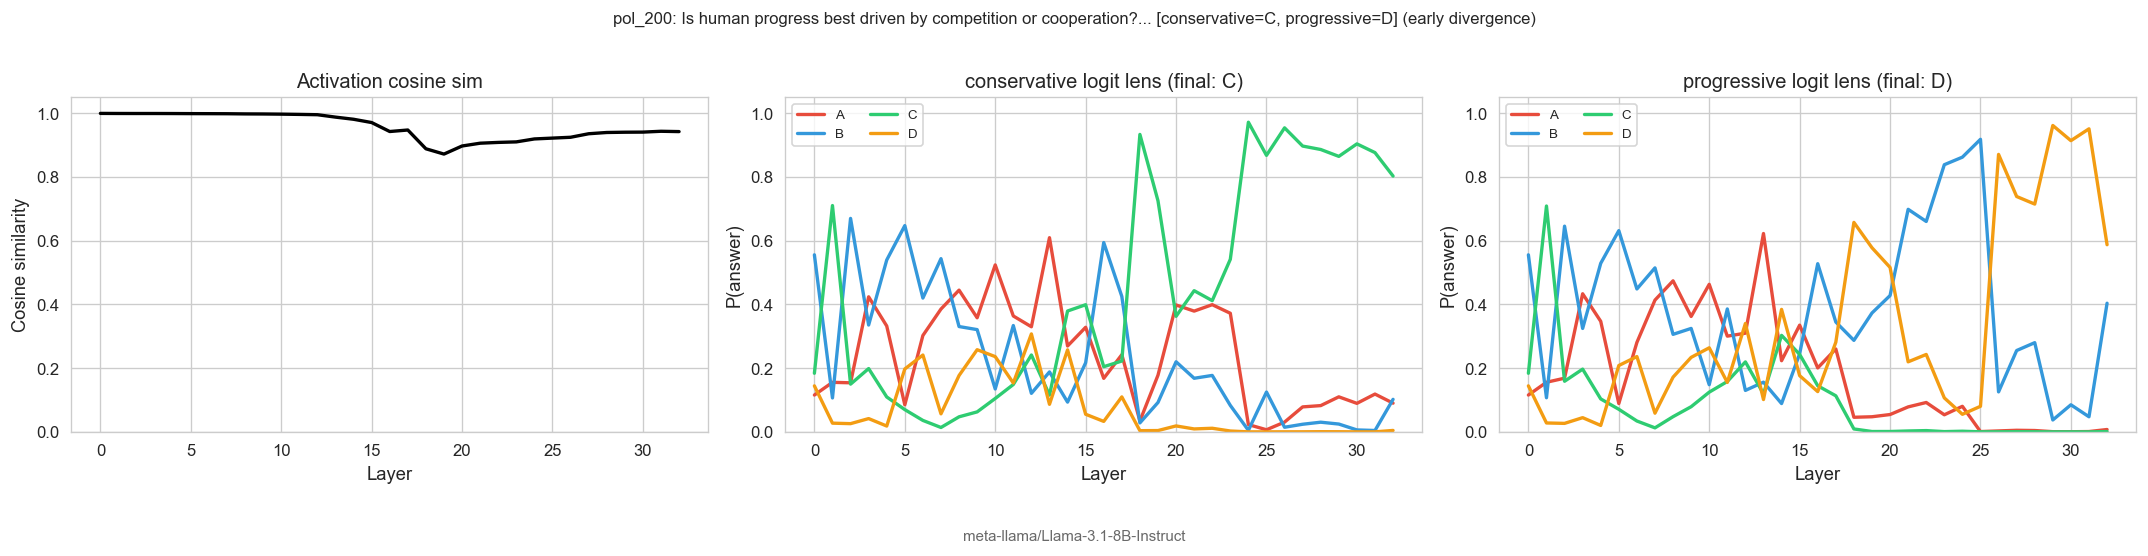

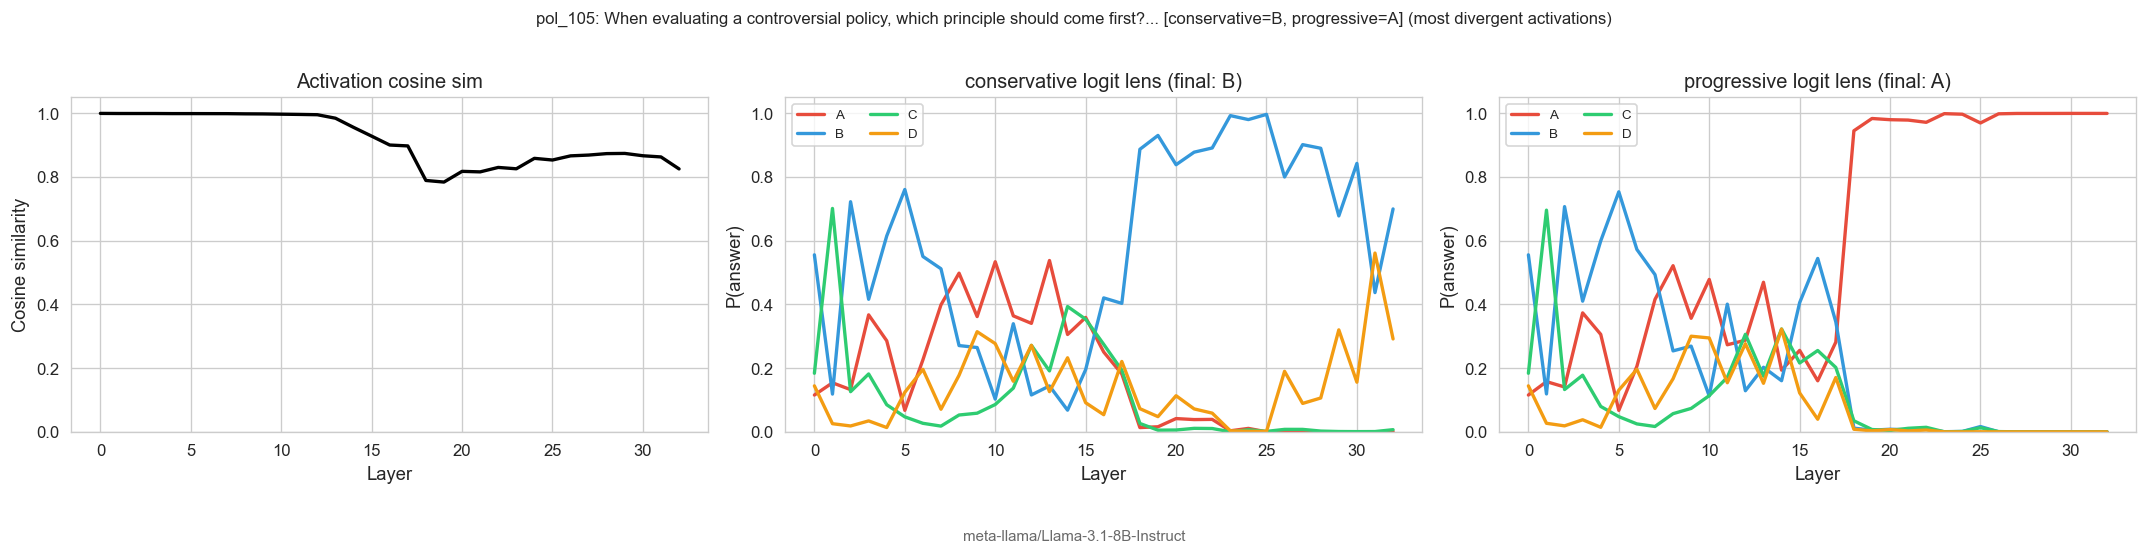

In [27]:
# ── Paired trajectory case studies ────────────────────────────────────
def plot_case_study(qi, title_suffix=""):
    """Plot cosine sim + logit-lens probs for a single question."""
    qid = QUESTION_IDS[qi]
    q_text = questions_map[qid].get("question_text", qid)[:100]
    p1_ans = logits_df[(logits_df["persona"] == P1) & (logits_df["question_id"] == qid)]["chosen_answer"].values[0]
    p2_ans = logits_df[(logits_df["persona"] == P2) & (logits_df["question_id"] == qid)]["chosen_answer"].values[0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Panel 1: Cosine similarity
    ax = axes[0]
    sim = cos_sim[qi].numpy()
    ax.plot(layers, sim, "k-", linewidth=2)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Cosine similarity")
    ax.set_title("Activation cosine sim")
    ax.set_ylim(0, 1.05)

    # Panels 2-3: Logit-lens answer probs for each persona
    colors_ans = {"A": "#e74c3c", "B": "#3498db", "C": "#2ecc71", "D": "#f39c12"}
    for ax, p, p_label in [(axes[1], P1, p1_short), (axes[2], P2, p2_short)]:
        probs = ll_probs[p][qi].numpy()  # [n_layers, 4]
        for ci, ch in enumerate(CHOICES):
            ax.plot(layers, probs[:, ci], color=colors_ans[ch], linewidth=2, label=ch)
        final_ans = p1_ans if p == P1 else p2_ans
        ax.set_title(f"{p_label} logit lens (final: {final_ans})")
        ax.set_xlabel("Layer")
        ax.set_ylabel("P(answer)")
        ax.legend(fontsize=8, ncol=2)
        ax.set_ylim(0, 1.05)

    fig.suptitle(f"{qid}: {q_text}... [{p1_short}={p1_ans}, {p2_short}={p2_ans}] {title_suffix}",
                 fontsize=10, y=1.02)
    _model_footer(fig, MODEL_NAME, y=-0.06)
    plt.tight_layout()
    plt.show()

# Pick representative examples
agree_indices = agree_mask.numpy().nonzero()[0]
disagree_indices_arr = disagree_mask.numpy().nonzero()[0]

# 1. Agreement example: pick one with high cosine sim throughout
if len(agree_indices) > 0:
    best_agree = agree_indices[cos_sim[agree_indices, -1].argmax()]
    plot_case_study(best_agree, "(agreement)")

# 2. Late divergence: disagreement Q with latest logit-lens divergence onset
if len(disagree_indices_arr) > 0:
    late_div_q = disagree_indices_arr[divergence_layers.argmax()]
    plot_case_study(late_div_q, "(late divergence)")

    # 3. Early divergence: disagreement Q with earliest divergence onset
    early_div_q = disagree_indices_arr[divergence_layers.argmin()]
    plot_case_study(early_div_q, "(early divergence)")

    # 4. Outlier: disagreement Q with lowest final-layer cosine sim
    final_cos_disagree = cos_sim[disagree_indices_arr, -1]
    outlier_q = disagree_indices_arr[final_cos_disagree.argmin()]
    plot_case_study(outlier_q, "(most divergent activations)")

### Asymmetry analysis

Pure activation distance is symmetric (d(A,B) = d(B,A)), so we look for asymmetric signals in the logit lens:

1. **Answer stabilization**: Which persona reaches a stable top-1 answer earlier? Earlier stabilization suggests the model commits to that persona's answer first.
2. **Other-answer persistence**: Does one persona preserve the other's final answer as plausible (top-2) longer than vice versa? If conservative's answer persists longer in progressive's logit lens than the reverse, that suggests conservative's answer is closer to a "shared default" that progressive must actively override.

These are pre-probe proxies for privileged-access-like effects.

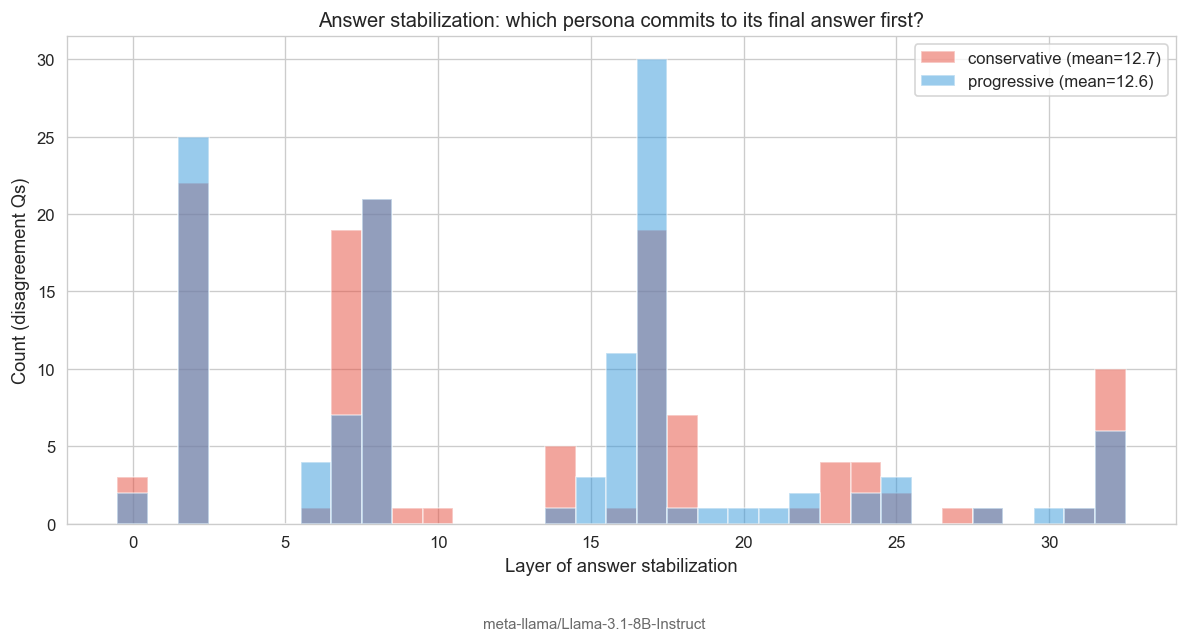

Mean stabilization: conservative=12.7, progressive=12.6
  → progressive stabilizes 0.1 layers earlier on average


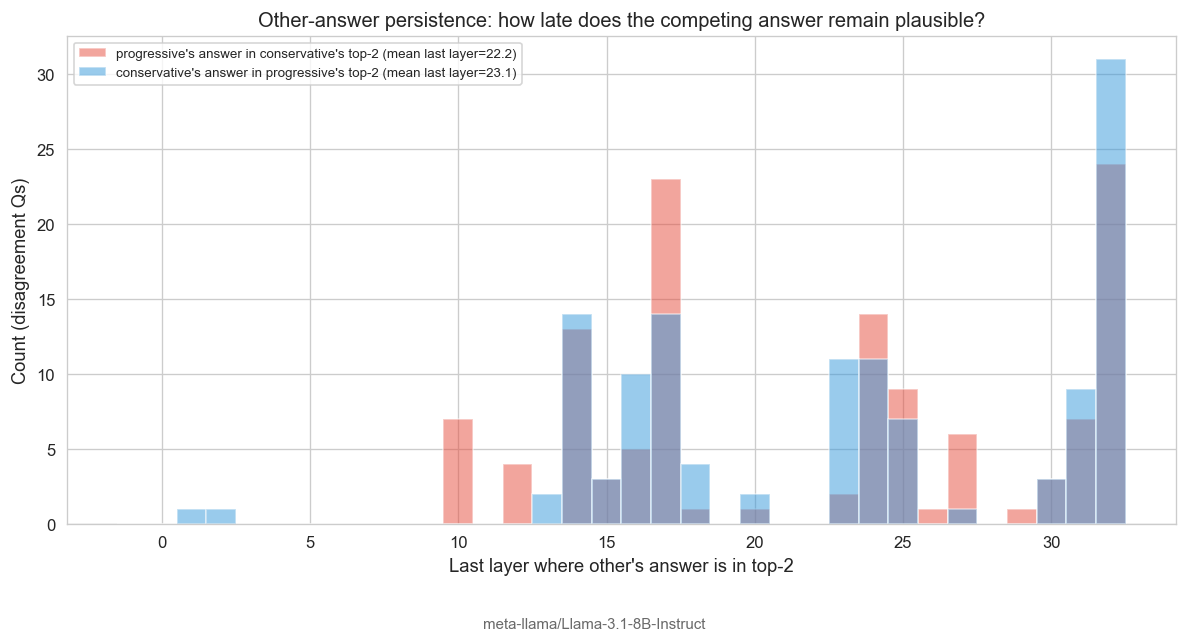

Mean last layer of other's answer in top-2:
  conservative's answer in progressive's logit lens: 23.1
  progressive's answer in conservative's logit lens: 22.2
  → Roughly symmetric (diff=0.9 layers)


In [28]:
# ── Asymmetry analysis ────────────────────────────────────────────────

# 1. Answer stabilization: first layer where top-1 matches final and stays
stabilization = {}
for p in PERSONAS:
    stab_layers = []
    final_argmax = chosen_idx[p]  # [n_q]
    layer_argmax = ll_probs[p].argmax(dim=-1)  # [n_q, n_layers]
    for qi in disagree_idx:
        matches = (layer_argmax[qi] == final_argmax[qi]).numpy()
        # Find first layer where it matches and stays (4/5 window)
        onset = N_LAYERS - 1
        for l in range(N_LAYERS):
            remaining = N_LAYERS - l
            window = min(5, remaining)
            if matches[l:l + window].sum() >= min(4, window):
                onset = l
                break
        stab_layers.append(onset)
    stabilization[p] = np.array(stab_layers)

fig, ax = plt.subplots(figsize=(10, 5))
for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
    label = p.replace("persona_", "")
    ax.hist(stabilization[p], bins=np.arange(0, N_LAYERS + 1) - 0.5,
            alpha=0.5, color=color, edgecolor="white", label=f"{label} (mean={stabilization[p].mean():.1f})")
ax.set_xlabel("Layer of answer stabilization")
ax.set_ylabel("Count (disagreement Qs)")
ax.set_title("Answer stabilization: which persona commits to its final answer first?")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

stab_diff = stabilization[P1].mean() - stabilization[P2].mean()
earlier_p = p1_short if stab_diff < 0 else p2_short
print(f"Mean stabilization: {p1_short}={stabilization[P1].mean():.1f}, "
      f"{p2_short}={stabilization[P2].mean():.1f}")
print(f"  → {earlier_p} stabilizes {abs(stab_diff):.1f} layers earlier on average")

# 2. Other-answer persistence: last layer where other's answer is in top-2
persistence = {}
for owner_p, other_p in [(P1, P2), (P2, P1)]:
    last_top2 = []
    for qi in disagree_idx:
        other_ans_idx = chosen_idx[other_p][qi].item()
        probs = ll_probs[owner_p][qi]  # [n_layers, 4]
        top2 = probs.topk(2, dim=-1).indices  # [n_layers, 2]
        in_top2 = (top2 == other_ans_idx).any(dim=-1).numpy()  # [n_layers]
        last_layer = -1
        for l in range(N_LAYERS - 1, -1, -1):
            if in_top2[l]:
                last_layer = l
                break
        last_top2.append(last_layer)
    persistence[(owner_p, other_p)] = np.array(last_top2)

fig, ax = plt.subplots(figsize=(10, 5))
for (owner_p, other_p), color in [((P1, P2), "#e74c3c"), ((P2, P1), "#3498db")]:
    owner_short = owner_p.replace("persona_", "")
    other_short = other_p.replace("persona_", "")
    data = persistence[(owner_p, other_p)]
    label = f"{other_short}'s answer in {owner_short}'s top-2 (mean last layer={data.mean():.1f})"
    ax.hist(data, bins=np.arange(-1, N_LAYERS + 1) - 0.5,
            alpha=0.5, color=color, edgecolor="white", label=label)
ax.set_xlabel("Last layer where other's answer is in top-2")
ax.set_ylabel("Count (disagreement Qs)")
ax.set_title("Other-answer persistence: how late does the competing answer remain plausible?")
ax.legend(fontsize=8)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Asymmetry score
p1_in_p2 = persistence[(P2, P1)].mean()  # P1's answer persisting in P2's state
p2_in_p1 = persistence[(P1, P2)].mean()  # P2's answer persisting in P1's state
print(f"Mean last layer of other's answer in top-2:")
print(f"  {p1_short}'s answer in {p2_short}'s logit lens: {p1_in_p2:.1f}")
print(f"  {p2_short}'s answer in {p1_short}'s logit lens: {p2_in_p1:.1f}")
asymmetry = p1_in_p2 - p2_in_p1
if abs(asymmetry) > 1.0:
    longer_p = p1_short if asymmetry > 0 else p2_short
    print(f"  → {longer_p}'s answer persists {abs(asymmetry):.1f} layers longer in the other persona's state")
else:
    print(f"  → Roughly symmetric (diff={asymmetry:.1f} layers)")

### Relating activation divergence to logit-lens divergence

Do the activation-level and prediction-level divergence measures agree? We check:
1. **Does larger activation distance predict disagreement?** (scatter: final-layer cosine distance vs agreement/disagreement)
2. **Does logit-lens divergence onset correlate with activation divergence onset?** (scatter of the two onset layers per question)

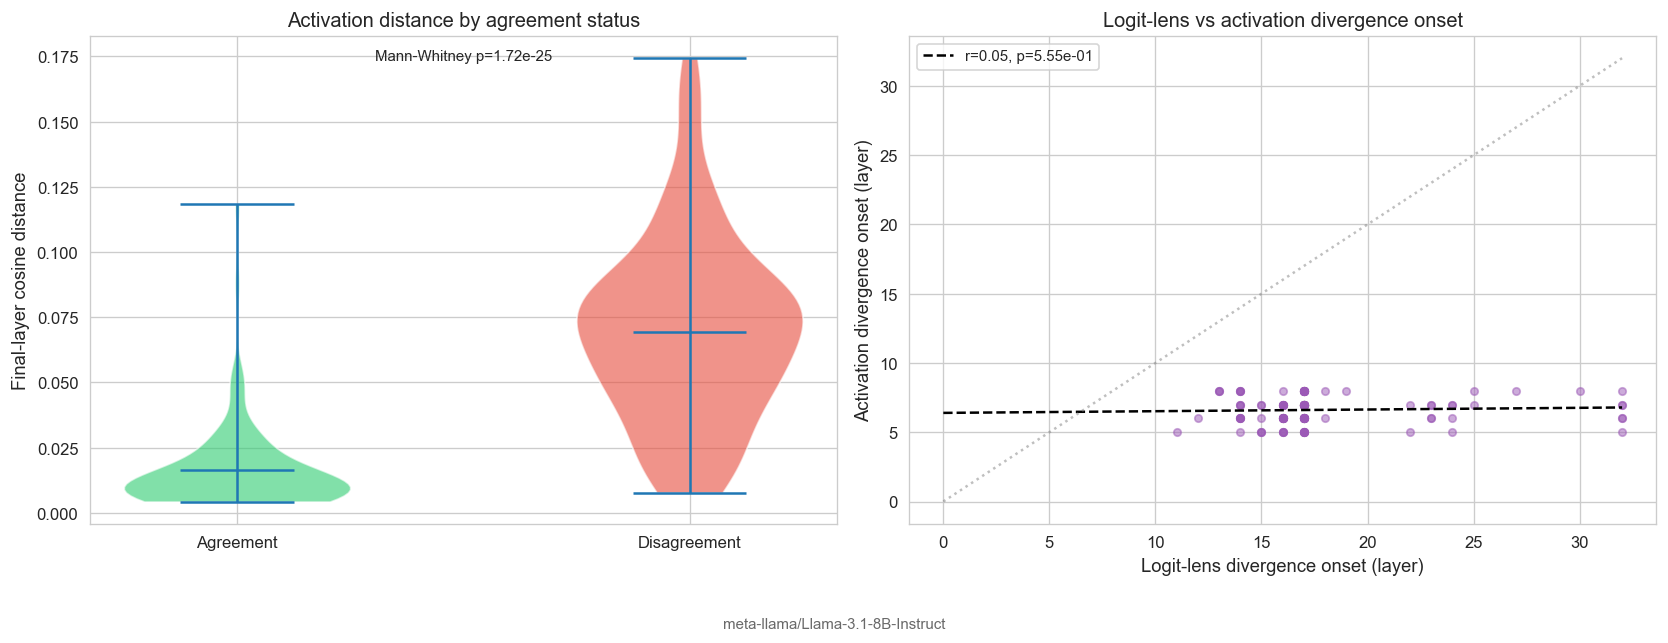

In [29]:
# ── Correlations: activation distance vs logit-lens divergence ────────
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Final-layer cosine distance vs agreement/disagreement
ax = axes[0]
final_cos_dist = (1 - cos_sim[:, -1]).numpy()
agree_dists = final_cos_dist[agree_mask.numpy()]
disagree_dists = final_cos_dist[disagree_mask.numpy()]

parts = ax.violinplot([agree_dists, disagree_dists], positions=[0, 1], showmeans=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(["#2ecc71", "#e74c3c"][i])
    pc.set_alpha(0.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Agreement", "Disagreement"])
ax.set_ylabel("Final-layer cosine distance")
ax.set_title("Activation distance by agreement status")

# Mann-Whitney test
u_stat, p_val = stats.mannwhitneyu(agree_dists, disagree_dists, alternative="less")
ax.text(0.5, 0.95, f"Mann-Whitney p={p_val:.2e}", transform=ax.transAxes,
        ha="center", fontsize=9)

# 2. Logit-lens onset vs activation onset (disagreement only)
ax = axes[1]
act_onset_dis = act_onset[disagree_mask.numpy()]
ll_onset_dis = divergence_layers  # already disagreement-only
if len(act_onset_dis) == len(ll_onset_dis):
    ax.scatter(ll_onset_dis, act_onset_dis, alpha=0.5, s=20, color="#9b59b6")
    # Add regression line
    slope, intercept, r, p, se = stats.linregress(ll_onset_dis, act_onset_dis)
    x_line = np.array([0, N_LAYERS - 1])
    ax.plot(x_line, slope * x_line + intercept, "k--", linewidth=1.5,
            label=f"r={r:.2f}, p={p:.2e}")
    ax.plot([0, N_LAYERS - 1], [0, N_LAYERS - 1], ":", color="gray", alpha=0.5)
    ax.set_xlabel("Logit-lens divergence onset (layer)")
    ax.set_ylabel("Activation divergence onset (layer)")
    ax.set_title("Logit-lens vs activation divergence onset")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, f"Size mismatch: {len(act_onset_dis)} vs {len(ll_onset_dis)}", ha="center")

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Nearest-centroid pseudo-decoding (exploratory)

**This is a crude proxy for linear probes, not a substitute.** For each layer and persona, we compute class centroids (mean activation per answer A/B/C/D), then classify each question by nearest centroid. We then check whether cross-persona nearest-centroid classification works (i.e., using one persona's centroids on the other persona's activations).

This is intentionally simple and labeled as exploratory — proper linear probes are in Section 5.

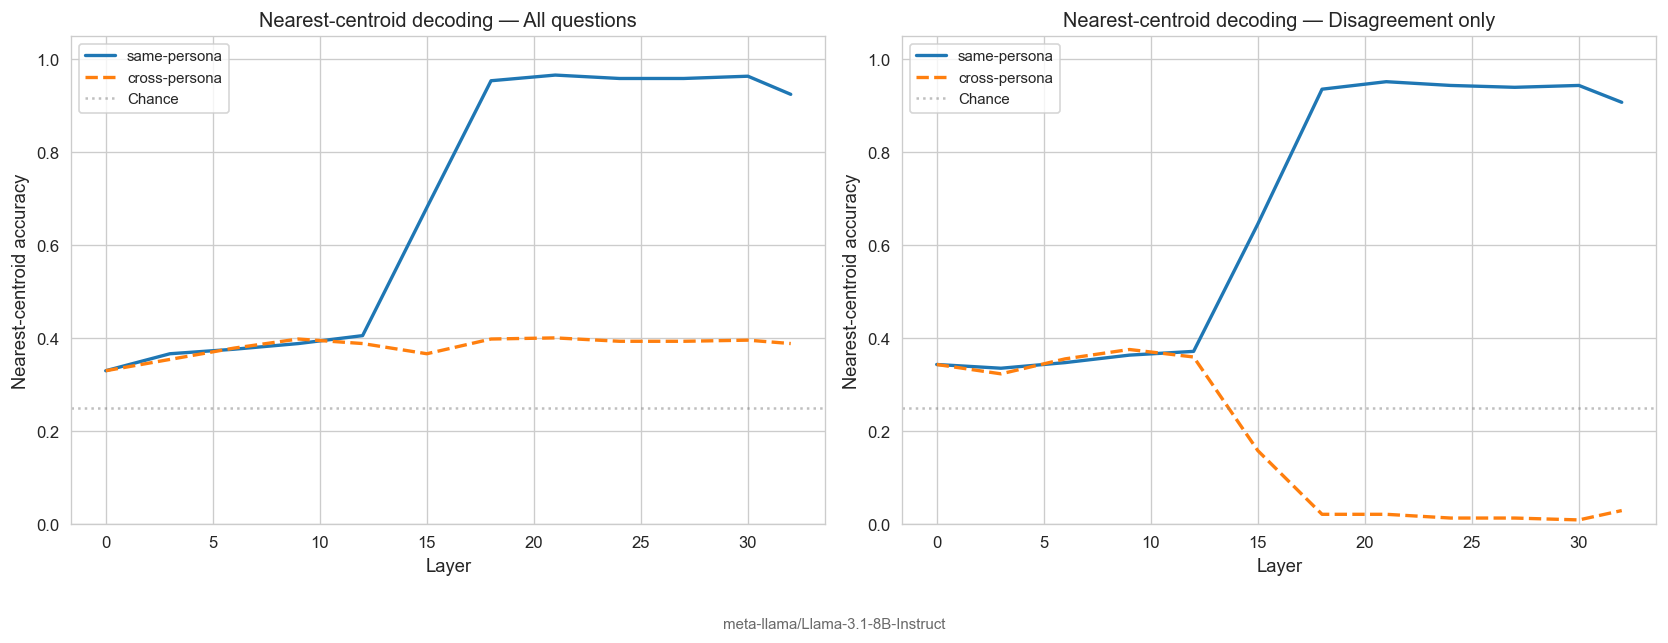

Note: this is a crude baseline — see Section 5 for proper linear probes.


In [30]:
# ── Nearest-centroid pseudo-decoding ──────────────────────────────────
# Build answer labels per persona
nc_answers = {}
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
    nc_answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

layer_picks_nc = sorted(set([0] + list(range(0, N_LAYERS, max(1, N_LAYERS // 10))) + [N_LAYERS - 1]))

nc_results = []
for layer in layer_picks_nc:
    for centroid_p in PERSONAS:
        # Compute centroids from centroid_p's activations
        acts_c = activations[centroid_p][:, layer, :].float()
        centroids = {}
        for ans in CHOICES:
            mask = (nc_answers[centroid_p] == ans)
            if mask.sum() > 0:
                centroids[ans] = acts_c[mask].mean(dim=0)

        if len(centroids) < 2:
            continue

        centroid_tensor = torch.stack([centroids[ans] for ans in CHOICES if ans in centroids])
        centroid_labels = [ans for ans in CHOICES if ans in centroids]

        # Classify using both personas' activations
        for eval_p in PERSONAS:
            acts_e = activations[eval_p][:, layer, :].float()
            # Cosine similarity to each centroid
            sims = torch.nn.functional.cosine_similarity(
                acts_e.unsqueeze(1), centroid_tensor.unsqueeze(0), dim=-1
            )  # [n_q, n_centroids]
            preds = [centroid_labels[i] for i in sims.argmax(dim=1).numpy()]
            true = nc_answers[centroid_p]  # scored against centroid persona's answers
            acc_all = np.mean([p == t for p, t in zip(preds, true)])

            # Disagreement only
            dis_mask = disagree_mask.numpy()
            if dis_mask.sum() > 0:
                acc_dis = np.mean([p == t for p, t, m in zip(preds, true, dis_mask) if m])
            else:
                acc_dis = None

            combo = "same" if centroid_p == eval_p else "cross"
            nc_results.append({
                "layer": layer,
                "centroid_persona": centroid_p.replace("persona_", ""),
                "eval_persona": eval_p.replace("persona_", ""),
                "combo": combo,
                "accuracy_full": acc_all,
                "accuracy_disagree": acc_dis,
            })

nc_df = pd.DataFrame(nc_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], "accuracy_full", "All questions"),
    (axes[1], "accuracy_disagree", "Disagreement only"),
]:
    for combo, style in [("same", "-"), ("cross", "--")]:
        sub = nc_df[nc_df["combo"] == combo].groupby("layer")[col].mean()
        ax.plot(sub.index, sub.values, style, linewidth=2, label=f"{combo}-persona")
    ax.axhline(1.0 / len(CHOICES), color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Nearest-centroid accuracy")
    ax.set_title(f"Nearest-centroid decoding — {title}")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()
print("Note: this is a crude baseline — see Section 5 for proper linear probes.")

## 5. Linear Probes

### What are linear probes?

A **linear probe** is a simple logistic regression classifier trained on the model's hidden-state vectors. It answers: "given just the activations at layer L, can a linear classifier predict which answer (A/B/C/D) the model chose?"

We train probes using the separate script `scripts/train_probes.py`, which saves results to `<run_dir>/probes/`. This notebook **loads** those pre-computed results rather than retraining, ensuring a single source of truth.

**Two key probe types:**
- **Same-persona:** Train on Persona A's activations, predict Persona A's answers. High accuracy = the answer is linearly decodable.
- **Cross-persona:** Train on Persona A's activations, then evaluate on Persona B's activations while still scoring against Persona A's labels. High accuracy would mean both personas encode the same answer information. Low accuracy (especially on disagreement questions) means the personas encode genuinely different answers.

Run probes first: `python scripts/train_probes.py <run_dir>`

In [31]:
# ── Load pre-computed probes OR train inline ─────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm.auto import tqdm

probes_dir = RUN_DIR / "probes"
metrics_path = probes_dir / "probe_metrics.csv"

if metrics_path.exists():
    # ── LOAD from train_probes.py output ──────────────────────────────
    probe_metrics = pd.read_csv(metrics_path)
    print(f"Loaded {len(probe_metrics)} probe metric rows from {metrics_path}")

    predictions_path = probes_dir / "probe_predictions.csv"
    if predictions_path.exists():
        probe_predictions = pd.read_csv(predictions_path)
        print(f"Loaded {len(probe_predictions)} prediction rows")
    else:
        probe_predictions = None

    manifest_path = probes_dir / "split_manifest.json"
    if manifest_path.exists():
        with open(manifest_path) as f:
            split_manifest = json.load(f)
        print(f"Split: train={split_manifest['n_train']}, "
              f"val={split_manifest['n_val']}, test={split_manifest['n_test']}")
else:
    # ── TRAIN inline (no pre-computed probes found) ───────────────────
    print(f"No probes found at {probes_dir}, training inline...")

    answers = {}
    for p in PERSONAS:
        sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
        answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

    le = LabelEncoder()
    le.fit(np.concatenate([answers[p] for p in PERSONAS]))
    labels = {p: le.transform(answers[p]) for p in PERSONAS}

    # 60/20/20 split (matches train_probes.py logic)
    rng = np.random.RandomState(42)
    indices = np.arange(N_QUESTIONS)
    rng.shuffle(indices)
    n_test = max(1, int(0.2 * N_QUESTIONS))
    n_val = max(1, int(0.2 * N_QUESTIONS))
    train_idx = indices[:N_QUESTIONS - n_val - n_test]
    val_idx = indices[N_QUESTIONS - n_val - n_test:N_QUESTIONS - n_test]
    test_idx = indices[N_QUESTIONS - n_test:]

    test_agree = agree_mask.numpy()[test_idx]
    test_disagree = disagree_mask.numpy()[test_idx]

    print(f"Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
    print(f"Test set: {test_agree.sum()} agreement, {test_disagree.sum()} disagreement")

    eval_combos = []
    for probe_p in PERSONAS:
        other_p = [p for p in PERSONAS if p != probe_p][0]
        eval_combos.append((probe_p, probe_p, "same_persona"))
        eval_combos.append((probe_p, other_p, "cross_persona"))

    C_VALUES = [0.01, 0.1, 1.0, 10.0]
    metric_rows = []

    for layer in tqdm(range(N_LAYERS), desc="Training probes"):
        probes_dict = {}
        scalers_dict = {}

        for pname in PERSONAS:
            X_all = activations[pname][:, layer, :].float().numpy()
            y_all = labels[pname]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_all[train_idx])
            X_val = scaler.transform(X_all[val_idx])
            y_train, y_val = y_all[train_idx], y_all[val_idx]

            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            probes_dict[pname] = best_clf
            scalers_dict[pname] = scaler

        for probe_p, act_p, combo_type in eval_combos:
            probe = probes_dict[probe_p]
            scaler = scalers_dict[probe_p]
            X_test = scaler.transform(activations[act_p][:, layer, :].float().numpy()[test_idx])
            y_test = labels[probe_p][test_idx]

            for subset_name, subset_mask in [("full", None), ("agreement", test_agree),
                                              ("disagreement", test_disagree)]:
                if subset_mask is not None:
                    if subset_mask.sum() == 0:
                        continue
                    acc = float(probe.score(X_test[subset_mask], y_test[subset_mask]))
                    n_s = int(subset_mask.sum())
                else:
                    acc = float(probe.score(X_test, y_test))
                    n_s = len(y_test)
                metric_rows.append({
                    "layer": layer, "probe_persona": probe_p,
                    "activation_persona": act_p, "combo_type": combo_type,
                    "subset": subset_name, "accuracy": acc, "n_samples": n_s,
                })

    probe_metrics = pd.DataFrame(metric_rows)
    print(f"Trained probes at all {N_LAYERS} layers. {len(probe_metrics)} metric rows.")

# Quick summary
for combo in probe_metrics["combo_type"].unique():
    sub = probe_metrics[(probe_metrics["combo_type"] == combo) &
                        (probe_metrics["subset"] == "full")]
    final = sub[sub["layer"] == sub["layer"].max()]
    mean_acc = final["accuracy"].mean()
    print(f"  {combo:15s} final-layer accuracy (full): {mean_acc:.3f}")

No probes found at /Users/daylight/dev/code/cross_persona_introspection/results/raw/activation_probing_20260305_001035 llama 8b Instruct/probes, training inline...
Split: train=123, val=41, test=41
Test set: 10 agreement, 31 disagreement


Training probes:   0%|          | 0/33 [00:00<?, ?it/s]

Trained probes at all 33 layers. 396 metric rows.
  same_persona    final-layer accuracy (full): 0.915
  cross_persona   final-layer accuracy (full): 0.268


### Probe accuracy by layer

**Left panel (full):** Accuracy on all test questions. Solid lines = same-persona (baseline), dashed = cross-persona.

**Right panel (disagreement):** Accuracy only on questions where the personas gave different final answers. This is the most informative subset — on agreement questions, cross-persona probes trivially work since both personas chose the same answer.

**What to look for:**
- Same-persona accuracy should rise from chance (0.25) to near 1.0 in later layers
- The key question is the **gap** between solid and dashed lines in the disagreement panel. A large gap = deep persona effects. A small gap = shallow.

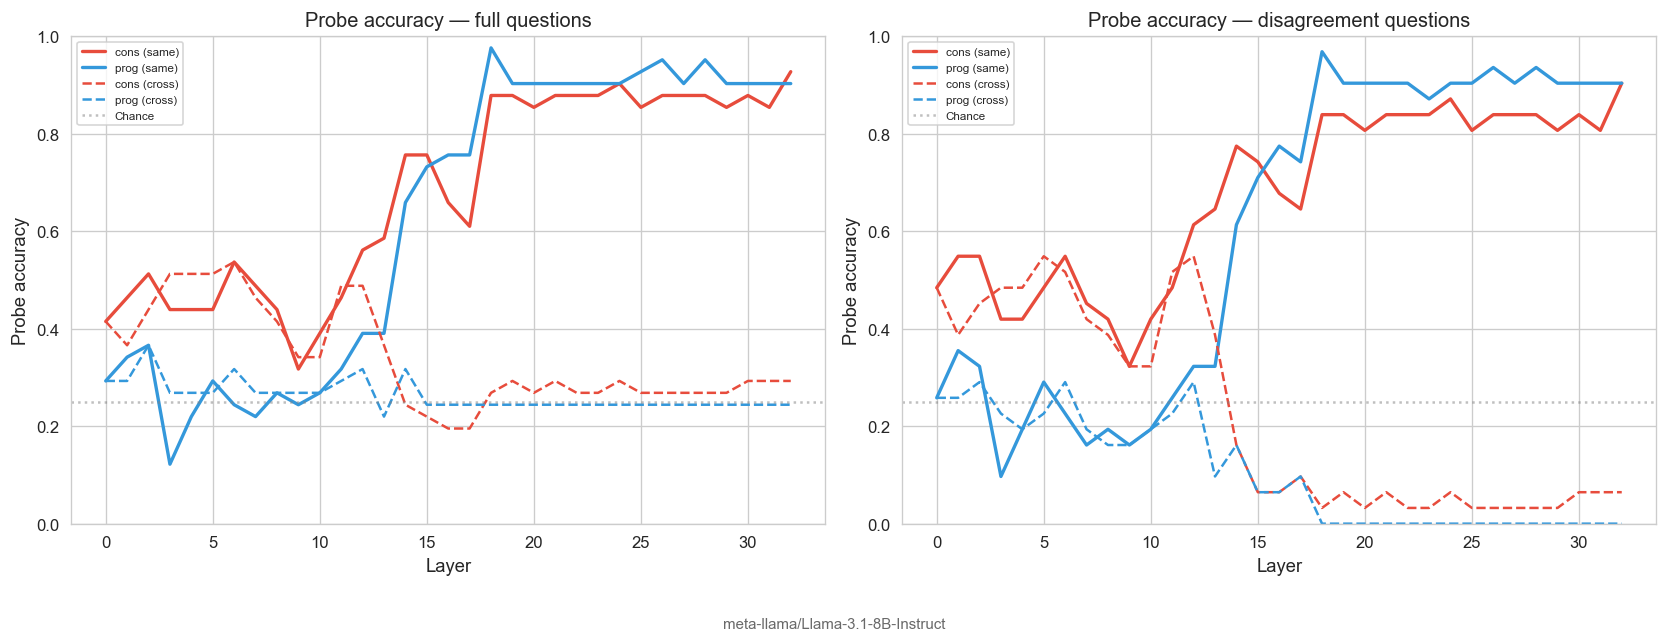

In [32]:
# ── Same-persona vs cross-persona probe accuracy by layer ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset in zip(axes, ["full", "disagreement"]):
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        ax.text(0.5, 0.5, f"No data for subset '{subset}'", ha="center")
        continue

    for combo_type, style, width in [("same_persona", "-", 2), ("cross_persona", "--", 1.5)]:
        combo_sub = sub[sub["combo_type"] == combo_type]
        for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
            p_sub = combo_sub[combo_sub["probe_persona"] == p].sort_values("layer")
            if p_sub.empty:
                continue
            label = f"{p.replace('persona_','')[:4]} ({combo_type.replace('_persona','')})"
            ax.plot(p_sub["layer"], p_sub["accuracy"], linestyle=style,
                    linewidth=width, color=color, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Probe accuracy")
    ax.set_title(f"Probe accuracy \u2014 {subset} questions")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Probe accuracy gap (same minus cross)

This directly plots the difference: same-persona accuracy minus cross-persona accuracy at each layer.

- **Positive gap** = the model's hidden states encode persona-specific information that doesn't transfer to the other persona. The persona has changed the internal representation.
- **Gap near zero** = the hidden states are interchangeable between personas. The persona effect is shallow.
- **Solid line** = all questions. **Dashed line** = disagreement questions only (more informative).

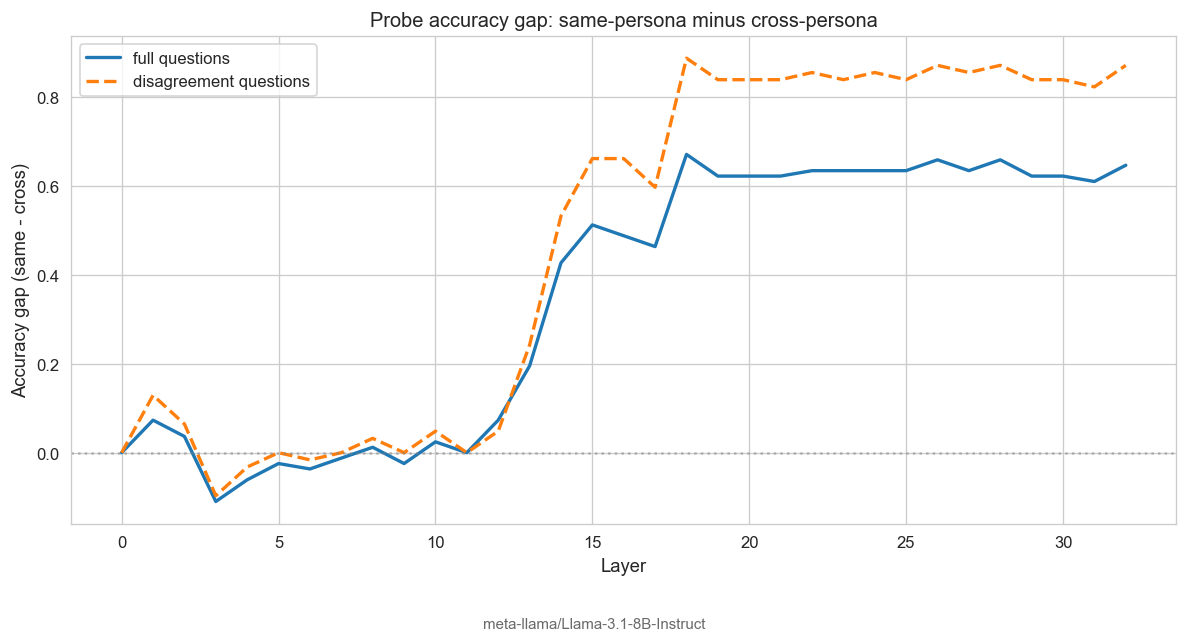

Positive gap = activations encode persona-specific answer information.
Negative gap = other persona's activations are MORE informative (unlikely).


In [33]:
# ── Probe accuracy gap: same - cross persona ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for subset, style in [("full", "-"), ("disagreement", "--")]:
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        continue
    same = sub[sub["combo_type"] == "same_persona"].groupby("layer")["accuracy"].mean()
    cross = sub[sub["combo_type"] == "cross_persona"].groupby("layer")["accuracy"].mean()
    gap = same - cross
    gap = gap.dropna()
    ax.plot(gap.index, gap.values, linestyle=style, linewidth=2, label=f"{subset} questions")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy gap (same - cross)")
ax.set_title("Probe accuracy gap: same-persona minus cross-persona")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print("Positive gap = activations encode persona-specific answer information.")
print("Negative gap = other persona's activations are MORE informative (unlikely).")

### Persona identity probe: is the persona itself encoded in activations?

A different probe: given a hidden state vector, can we tell whether it came from the conservative or progressive persona? This is a binary classification (50% chance baseline).

- **High accuracy** (near 100%) = the model's internal state is measurably different between personas at that layer. The system prompt has left a "fingerprint" in the hidden states.
- **Near chance** (50%) = the hidden states are indistinguishable between personas at that layer.

**Note:** High persona identity accuracy doesn't necessarily mean the *answer* differs — even on agreement questions, the system prompt text is different, so early layers will likely show high identity accuracy just from the prompt tokens. The interesting signal is whether identity accuracy *stays* high through the later layers where the model is computing its answer.

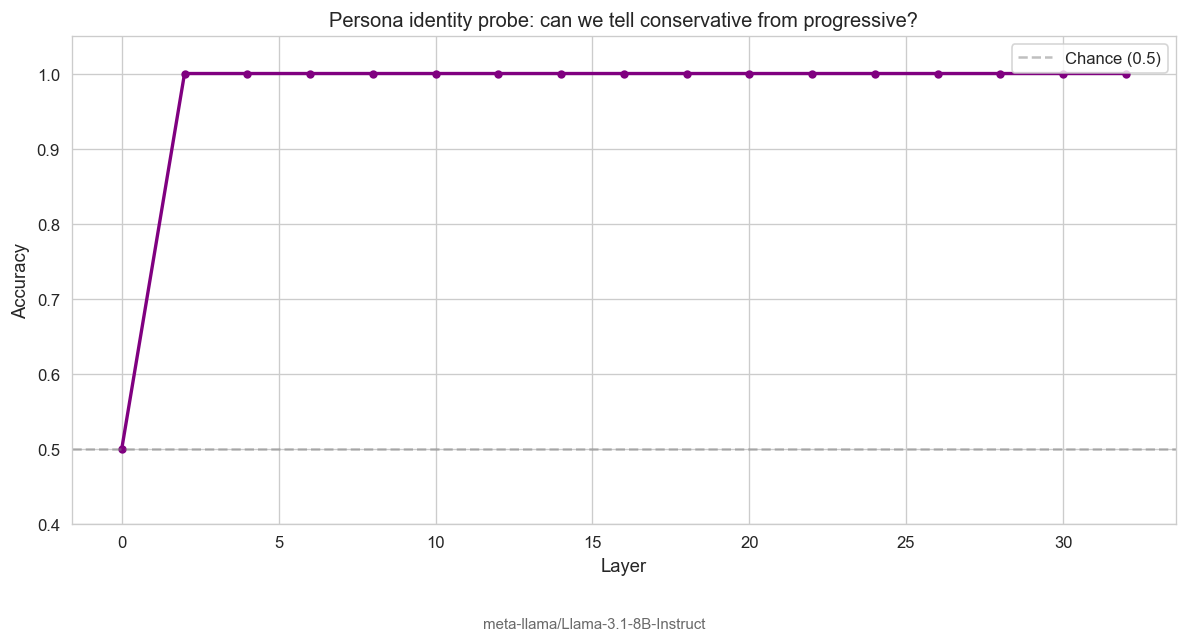

Final layer persona identification accuracy: 1.000


In [34]:
# ── Persona identity probe: can we tell WHICH persona from activations? ─
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

id_layers = sorted(set([0] + list(range(0, N_LAYERS, 2)) + [N_LAYERS - 1]))
id_results = []

rng = np.random.RandomState(42)
indices = np.arange(N_QUESTIONS)
rng.shuffle(indices)
n_train = int(0.7 * N_QUESTIONS)
train_idx_id = indices[:n_train]
test_idx_id = indices[n_train:]

for layer in id_layers:
    x1 = act_p1[:, layer, :].numpy()
    x2 = act_p2[:, layer, :].numpy()
    X_train = np.concatenate([x1[train_idx_id], x2[train_idx_id]], axis=0)
    y_train = np.array([0] * len(train_idx_id) + [1] * len(train_idx_id))
    X_test = np.concatenate([x1[test_idx_id], x2[test_idx_id]], axis=0)
    y_test = np.array([0] * len(test_idx_id) + [1] * len(test_idx_id))

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    id_results.append({"layer": layer, "accuracy": acc})

id_df = pd.DataFrame(id_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(id_df["layer"], id_df["accuracy"], "o-", color="purple", linewidth=2, markersize=4)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (0.5)")
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Persona identity probe: can we tell conservative from progressive?")
ax.legend()
ax.set_ylim(0.4, 1.05)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Final layer persona identification accuracy: {id_df.iloc[-1]['accuracy']:.3f}")

## 6. Key Findings Summary

In [35]:
sep = "=" * 60
print(sep)
print("KEY FINDINGS")
print(sep)

print(f"\nModel: {MODEL_NAME}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}, d_model: {D_MODEL}")

print(f"\n1. AGREEMENT / DISAGREEMENT")
print(f"   Overall: {n_agree}/{total} agree ({100*n_agree/total:.1f}%), "
      f"{n_disagree}/{total} disagree ({100*n_disagree/total:.1f}%)")
for _, row in cat_summary.iterrows():
    print(f"   {row['cat_short']:<20s}: {row['disagree_rate']:.0f}% disagree (n={int(row['n'])})")

print(f"\n2. LOGIT LENS — DIVERGENCE ONSET")
if len(divergence_layers) > 0:
    print(f"   Mean layer of persona divergence: {divergence_layers.mean():.1f} / {N_LAYERS-1}")
    print(f"   Median: {np.median(divergence_layers):.0f}")
    pct_early = (divergence_layers < N_LAYERS // 2).mean() * 100
    print(f"   {pct_early:.0f}% of divergences begin in first half of network")

print(f"\n3. ACTIVATION SIMILARITY")
final_cos_all = cos_sim[:, -1].mean().item()
final_cos_agree = cos_sim[agree_mask][:, -1].mean().item() if agree_mask.sum() > 0 else float('nan')
final_cos_disagree = cos_sim[disagree_mask][:, -1].mean().item() if disagree_mask.sum() > 0 else float('nan')
print(f"   Final layer cosine sim (all):          {final_cos_all:.4f}")
print(f"   Final layer cosine sim (agreement):    {final_cos_agree:.4f}")
print(f"   Final layer cosine sim (disagreement): {final_cos_disagree:.4f}")

print(f"\n4. ACTIVATION DIVERGENCE ONSET")
print(f"   Agreement Qs:    mean={act_onset[agree_mask.numpy()].mean():.1f} ± {act_onset[agree_mask.numpy()].std():.1f}")
print(f"   Disagreement Qs: mean={act_onset[disagree_mask.numpy()].mean():.1f} ± {act_onset[disagree_mask.numpy()].std():.1f}")

print(f"\n5. OTHER-ANSWER PERSISTENCE (disagreement Qs)")
for (owner_p, other_p) in [(P1, P2), (P2, P1)]:
    owner_s = owner_p.replace("persona_", "")
    other_s = other_p.replace("persona_", "")
    mean_last = persistence[(owner_p, other_p)].mean()
    print(f"   {other_s}'s answer in {owner_s}'s top-2 until layer: {mean_last:.1f}")

print(f"\n6. ASYMMETRY")
print(f"   Answer stabilization: {p1_short}={stabilization[P1].mean():.1f}, "
      f"{p2_short}={stabilization[P2].mean():.1f}")
print(f"   Stabilization gap: {abs(stab_diff):.1f} layers ({earlier_p} commits earlier)")

print(f"\n7. PROBES")
last_layer = probe_metrics["layer"].max()
last_full = probe_metrics[(probe_metrics["layer"] == last_layer) & (probe_metrics["subset"] == "full")]
for _, row in last_full.iterrows():
    print(f"   Layer {int(row['layer'])} {row['combo_type']:<15s} "
          f"probe={row['probe_persona'].replace('persona_','')[:4]} "
          f"acts={row['activation_persona'].replace('persona_','')[:4]}  "
          f"acc={row['accuracy']:.3f}")

print(f"\n8. PERSONA IDENTITY")
print(f"   Final layer persona ID accuracy: {id_df.iloc[-1]['accuracy']:.3f}")

print(f"\n{sep}")
print("INTERPRETATION")
print(sep)
print("""
Do the personas actually behave differently?
  → Check agreement rate and confusion matrix (Section 2)

When do their internal states begin to separate?
  → Logit-lens divergence onset and activation divergence onset (Sections 3-4)

Is that separation earlier on disagreement items?
  → Compare activation divergence onset: agreement vs disagreement (Section 4)

Does the losing persona's answer remain internally available?
  → Other-answer persistence and top-k survival curves (Section 3)

Is there evidence that one persona stays closer to the shared trajectory?
  → Asymmetry: stabilization timing and answer persistence (Section 4)

Is persona-specific information linearly decodable?
  → Same-persona vs cross-persona probes (Section 5)
""")

KEY FINDINGS

Model: meta-llama/Llama-3.1-8B-Instruct
Questions: 205, Layers: 33, d_model: 4096

1. AGREEMENT / DISAGREEMENT
   Overall: 81/205 agree (39.5%), 124/205 disagree (60.5%)
   Ambiguous           : 44% disagree (n=36)
   Ethics (mod)        : 44% disagree (n=36)
   Factual (ctrl)      : 6% disagree (n=35)
   Policy (high)       : 90% disagree (n=50)
   Values (high)       : 94% disagree (n=48)

2. LOGIT LENS — DIVERGENCE ONSET
   Mean layer of persona divergence: 17.8 / 32
   Median: 17
   19% of divergences begin in first half of network

3. ACTIVATION SIMILARITY
   Final layer cosine sim (all):          0.9515
   Final layer cosine sim (agreement):    0.9836
   Final layer cosine sim (disagreement): 0.9305

4. ACTIVATION DIVERGENCE ONSET
   Agreement Qs:    mean=7.2 ± 1.0
   Disagreement Qs: mean=6.6 ± 1.0

5. OTHER-ANSWER PERSISTENCE (disagreement Qs)
   progressive's answer in conservative's top-2 until layer: 22.2
   conservative's answer in progressive's top-2 until la